# Notebook 08 — n=1 Scalar-Parameter and Replication Robustness

## 1. Title and objective

This notebook tests whether the frozen dense-periodic $n=1$ benchmark remains informative when one scalar parameter changes at a time and when stochastic paths are repeated across independent shock realisations. The estimator, forecasting workflow, and event calendar remain unchanged; cases within a seed share shocks and different seeds use independent banks. This is not a full factorial experiment.

Synthetic truth is for evaluation only and is never a fitting or forecasting input. Timing is $$E_i \longrightarrow \omega_{i+1} \longrightarrow X_{i+1}.$$ Event ages $0,\ldots,12$ correspond to state-series lags $+1,\ldots,+13$.

## 2. Load the frozen workflow

Notebook 06 provides the reusable simulator and frozen analysis pipeline. It is loaded with its internal self-tests disabled so this notebook can define a compact new experiment without modifying upstream work.

In [1]:
RUN_HELPER_SELF_TESTS = False
%run "./06_experiment_workflow_helpers.ipynb"

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_functions = [make_case_config, make_shock_bank, derive_timing, simulate_case, run_full_pipeline, summarise_case]
for function in required_functions:
    assert callable(function)
print('Frozen workflow helpers loaded.')

Helper self-tests skipped for downstream use.
Frozen workflow helpers loaded.


## 3. Frozen benchmark

Notebooks 00–07 use $\kappa=1.50$, $\theta=0.20$, $\nu=0.015$, $\rho=-0.35$, event amplitude $A=0.01$, and decay rate $\lambda=35$. The benchmark remains unchanged so every scalar case is directly comparable with earlier work.

In [2]:
benchmark_case = make_case_config(reference_config, label='benchmark')
benchmark_snapshot = copy.deepcopy(benchmark_case)
reference_snapshot = copy.deepcopy(reference_config)
benchmark_timing = derive_timing(benchmark_case)
benchmark_decay_rate = benchmark_case['events']['decay_rate']
benchmark_steps_per_year = benchmark_timing['steps_per_year']
benchmark_table = pd.DataFrame([{
    'n': benchmark_case['model']['n'], 'kappa': benchmark_case['model']['kappa'], 'theta': benchmark_case['model']['theta'],
    'nu_0': benchmark_case['model']['nu_0'], 'rho_0': benchmark_case['model']['rho_0'],
    'event amplitude': benchmark_case['events']['amplitude'], 'event decay rate': benchmark_case['events']['decay_rate'],
    'event period': benchmark_timing['event_period_steps'], 'response horizon': benchmark_timing['response_horizon_steps'],
    'simulation years': benchmark_case['simulation']['years'], 'number of transitions': benchmark_case['simulation']['years'] * benchmark_case['simulation']['trading_steps_per_year'],
    'initial price': benchmark_case['simulation']['S0'], 'initial volatility': benchmark_case['simulation']['sigma0'],
}])
assert benchmark_case['model']['n'] == 1
assert benchmark_timing['event_period_steps'] == 21 and benchmark_timing['event_transition_ages'] == tuple(range(13))
assert (benchmark_timing['response_horizon_steps'] == 12 and not benchmark_timing['event_responses_overlap'])
display(benchmark_table)

,n,kappa,theta,nu_0,rho_0,event amplitude,event decay rate,event period,response horizon,simulation years,number of transitions,initial price,initial volatility
0,1,1.5,0.2,0.015,-0.35,0.01,35.0,21,12,2,504,100.0,0.2


## 4. Mean-reversion speed ($\kappa$)

$\kappa$ controls the pull of volatility towards its long-run level. The benchmark is $1.50$; the cases are $0.75$ (weaker reversion) and $3.00$ (stronger reversion). Stronger reversion may make event effects disappear more quickly, while weaker reversion may let them persist. All other parameters remain fixed.

## 5. Long-run volatility level ($\theta$)

$\theta$ is the long-run volatility level. The cases are $0.15$, $0.20$ (benchmark), and $0.25$. Initial volatility remains fixed at $\sigma_0=0.20$ in every case: changing it alongside $\theta$ would not be a one-at-a-time experiment.

## 6. Volatility innovation scale ($\nu$)

$\nu$ controls the scale of stochastic volatility innovations. The cases are $0.0075$, $0.015$ (benchmark), and $0.0225$. Higher $\nu$ lowers event signal-to-noise and can make event detection and profile recovery harder.

## 7. Return-volatility correlation ($\rho$)

$\rho$ controls correlation between price and volatility innovations. The cases are $-0.70$ (`rho_more_negative`), $-0.35$ (benchmark), and $-0.05$ (`rho_near_zero`). This checks whether observable price innovation remains useful when the price-volatility relationship changes.

## 8. Event-response amplitude ($A$)

The response is $$\omega(\tau)=1+A\exp(-\lambda\tau),\qquad w=\omega(0)=1+A.$$ For $n=1$, the one-transition volatility multiplier is $\omega(\tau)^{1/2}$. The six revised scalar cases use common initial weights $w\in\{1.05,1.10,1.20,1.30,1.40,1.50\}$, or equivalently $A\in\{0.05,0.10,0.20,0.30,0.40,0.50\}$. The frozen benchmark remains $w=1.01$ ($A=0.01$).

Because ages $0,\ldots,12$ repeatedly apply the multiplier, larger weights are first a numerical-viability question for the unchanged Euler price transition $S_{t+1}=S_t(1+\sigma_t\epsilon_t)$. Prices, volatility, shocks, weights, residuals, and forecast errors are never clipped. Invalid complete paths remain visible and do not enter estimation or forecast summaries.


## 9. Event-decay rate ($\lambda$)

$\lambda$ controls response decay inside the fixed event-age horizon. The cases are $17.5$ (`decay_slow`), $35$ (benchmark), and $70$ (`decay_fast`). Only the response shape changes; the horizon remains ages 0 through 12.

## 10. Build the combined scalar case registry

The registry stores every planned one-at-a-time case in one tidy table. The benchmark appears once; each non-benchmark row changes exactly one intended scalar field. This avoids six duplicated configuration blocks before the later shared-pipeline loop.

In [3]:
case_rows = [
    {'case_name':'benchmark','parameter':'benchmark','setting':'benchmark','override_path':None,'parameter_value':np.nan,'benchmark_value':np.nan,'interpretation':'frozen dense-periodic reference'},
    {'case_name':'kappa_low','parameter':'kappa','setting':'low','override_path':'model.kappa','parameter_value':0.75,'benchmark_value':1.50,'interpretation':'weaker mean reversion'},
    {'case_name':'kappa_high','parameter':'kappa','setting':'high','override_path':'model.kappa','parameter_value':3.00,'benchmark_value':1.50,'interpretation':'stronger mean reversion'},
    {'case_name':'theta_low','parameter':'theta','setting':'low','override_path':'model.theta','parameter_value':0.15,'benchmark_value':0.20,'interpretation':'lower long-run volatility; sigma0 fixed'},
    {'case_name':'theta_high','parameter':'theta','setting':'high','override_path':'model.theta','parameter_value':0.25,'benchmark_value':0.20,'interpretation':'higher long-run volatility; sigma0 fixed'},
    {'case_name':'nu_low','parameter':'nu','setting':'low','override_path':'model.nu_0','parameter_value':0.0075,'benchmark_value':0.015,'interpretation':'lower volatility innovation scale'},
    {'case_name':'nu_high','parameter':'nu','setting':'high','override_path':'model.nu_0','parameter_value':0.0225,'benchmark_value':0.015,'interpretation':'higher volatility innovation scale'},
    {'case_name':'rho_more_negative','parameter':'rho','setting':'more_negative','override_path':'model.rho_0','parameter_value':-0.70,'benchmark_value':-0.35,'interpretation':'more negative return-volatility correlation'},
    {'case_name':'rho_near_zero','parameter':'rho','setting':'near_zero','override_path':'model.rho_0','parameter_value':-0.05,'benchmark_value':-0.35,'interpretation':'approximately uncorrelated innovations'},
    {'case_name':'weight_1_05','parameter':'amplitude','setting':'weight_1_05','override_path':'events.amplitude','parameter_value':0.05,'benchmark_value':0.01,'interpretation':'common initial event weight 1.05'},
    {'case_name':'weight_1_10','parameter':'amplitude','setting':'weight_1_10','override_path':'events.amplitude','parameter_value':0.10,'benchmark_value':0.01,'interpretation':'common initial event weight 1.10'},
    {'case_name':'weight_1_20','parameter':'amplitude','setting':'weight_1_20','override_path':'events.amplitude','parameter_value':0.20,'benchmark_value':0.01,'interpretation':'common initial event weight 1.20'},
    {'case_name':'weight_1_30','parameter':'amplitude','setting':'weight_1_30','override_path':'events.amplitude','parameter_value':0.30,'benchmark_value':0.01,'interpretation':'common initial event weight 1.30'},
    {'case_name':'weight_1_40','parameter':'amplitude','setting':'weight_1_40','override_path':'events.amplitude','parameter_value':0.40,'benchmark_value':0.01,'interpretation':'common initial event weight 1.40'},
    {'case_name':'weight_1_50','parameter':'amplitude','setting':'weight_1_50','override_path':'events.amplitude','parameter_value':0.50,'benchmark_value':0.01,'interpretation':'common initial event weight 1.50'},
    {'case_name':'decay_slow','parameter':'decay_rate','setting':'slow','override_path':'events.decay_rate','parameter_value':17.5,'benchmark_value':35.0,'interpretation':'slower, more persistent response'},
    {'case_name':'decay_fast','parameter':'decay_rate','setting':'fast','override_path':'events.decay_rate','parameter_value':70.0,'benchmark_value':35.0,'interpretation':'faster, shorter-lived response'},
]
case_registry = pd.DataFrame(case_rows)
case_registry['initial_event_weight'] = np.where(case_registry.parameter.eq('amplitude'), 1 + case_registry.parameter_value, np.where(case_registry.case_name.eq('benchmark'), 1 + benchmark_case['events']['amplitude'], np.nan))
intended_paths = {'model.kappa','model.theta','model.nu_0','model.rho_0','events.amplitude','events.decay_rate'}
common_weight_case_names = ['weight_1_05','weight_1_10','weight_1_20','weight_1_30','weight_1_40','weight_1_50']
assert len(case_registry) == 17 and case_registry.case_name.is_unique and case_registry.parameter.eq('benchmark').sum() == 1
assert case_registry.loc[case_registry.parameter.ne('benchmark'),'override_path'].isin(intended_paths).all()
assert case_registry.loc[case_registry.parameter.ne('benchmark'),'override_path'].notna().all()
assert case_registry.loc[case_registry.parameter.eq('amplitude'),'case_name'].tolist() == common_weight_case_names
assert np.allclose(case_registry.loc[case_registry.case_name.isin(common_weight_case_names),'initial_event_weight'], [1.05,1.10,1.20,1.30,1.40,1.50])
assert benchmark_case == benchmark_snapshot and reference_config == reference_snapshot
for _, row in case_registry.iterrows():
    config = benchmark_case if row.case_name == 'benchmark' else make_case_config(benchmark_case, {row.override_path: row.parameter_value}, label=row.case_name)
    assert config['model']['n'] == 1 and derive_timing(config) == benchmark_timing
assert benchmark_case == benchmark_snapshot and reference_config == reference_snapshot
display(case_registry)


,case_name,parameter,setting,override_path,parameter_value,benchmark_value,interpretation,initial_event_weight
0,benchmark,benchmark,benchmark,None,NaN,NaN,frozen dense-periodic reference,1.01
1,kappa_low,kappa,low,model.kappa,0.7500,1.500,weaker mean reversion,NaN
2,kappa_high,kappa,high,model.kappa,3.0000,1.500,stronger mean reversion,NaN
3,theta_low,theta,low,model.theta,0.1500,0.200,lower long-run volatility; sigma0 fixed,NaN
4,theta_high,theta,high,model.theta,0.2500,0.200,higher long-run volatility; sigma0 fixed,NaN
5,nu_low,nu,low,model.nu_0,0.0075,0.015,lower volatility innovation scale,NaN
6,nu_high,nu,high,model.nu_0,0.0225,0.015,higher volatility innovation scale,NaN
7,rho_more_negative,rho,more_negative,model.rho_0,-0.7000,-0.350,more negative return-volatility correlation,NaN
8,rho_near_zero,rho,near_zero,model.rho_0,-0.0500,-0.350,approximately uncorrelated innovations,NaN
9,weight_1_05,amplitude,weight_1_05,events.amplitude,0.0500,0.010,common initial event weight 1.05,1.05


## 11. Replication design

Robustness is assessed across 50 independent shock banks. One bank is shared by every active case within a seed, yielding paired comparisons; the next seed gets an independent bank. The planned run count is calculated dynamically as the number of active cases times 50.

In [4]:
MASTER_SEED = 20260721
N_SEEDS_INITIAL = 50
SEEDS = list(range(MASTER_SEED, MASTER_SEED + N_SEEDS_INITIAL))
planned_runs = N_SEEDS_INITIAL * len(case_registry)
workload_table = pd.DataFrame([{'number_of_seeds':N_SEEDS_INITIAL,'cases_per_seed':len(case_registry),'total_planned_runs':planned_runs}])
assert workload_table.loc[0,'total_planned_runs'] == len(SEEDS) * len(case_registry)
display(workload_table)

,number_of_seeds,cases_per_seed,total_planned_runs
0,50,17,850


## 12. Case-construction helper

This narrow helper converts one registry row into a complete configuration without mutating the benchmark. It is intentionally specific to this experiment and is not a new framework.

In [5]:
def construct_scalar_case(row):
    if row['case_name'] == 'benchmark':
        return copy.deepcopy(benchmark_case)
    return make_case_config(benchmark_case, {row['override_path']: row['parameter_value']}, label=row['case_name'])

def diagnose_frozen_simulation(case_config, shock_bank, functions=None):
    """Replay frozen transition equations only to identify a failed-path location; this never changes the simulator."""
    timing = derive_timing(case_config); steps = timing['steps_per_year']; n_steps = int(round(case_config['simulation']['years'] * steps))
    grid = np.arange(n_steps + 1, dtype=float) / steps; event_times = periodic_event_times(grid[0], grid[-2], case_config['events'])
    resolved, _ = resolve_model_functions(functions)
    S = float(case_config['simulation']['S0']); sigma = float(case_config['simulation']['sigma0']); x = sigma ** case_config['model']['n']
    returns = []; max_sigma = sigma; min_factor = np.inf
    for i in range(n_steps):
        t, dt = grid[i], grid[i + 1] - grid[i]
        alpha = float(resolved['alpha_fn'](t, S, sigma, np.asarray(returns), case_config['model']))
        nu = float(resolved['nu_fn'](t, S, sigma, np.asarray(returns), case_config['model']))
        rho = float(resolved['rho_fn'](t, S, sigma, np.asarray(returns), case_config['model']))
        omega = float(resolved['event_weight_fn'](t, event_times, case_config['events']))
        epsilon = shock_bank['z_epsilon'][i] * np.sqrt(dt); eta = shock_bank['z_eta'][i] * np.sqrt(dt)
        F = x + alpha * dt + nu * (rho * epsilon + np.sqrt(1.0-rho**2) * eta)
        x_next = omega ** (case_config['model']['n']/2) * F; sigma_next = x_next ** (1/case_config['model']['n']) if x_next > 0 else np.nan
        factor = 1 + sigma * epsilon; min_factor = min(min_factor, factor)
        active_ids = np.flatnonzero((t-event_times >= -1e-12) & (t-event_times <= case_config['events']['response_horizon']+1e-12))
        event_id = int(active_ids[0]) if len(active_ids) else np.nan
        event_age = int(round((t-event_times[event_id])*steps)) if len(active_ids) else np.nan
        meta = {'simulation_valid':False,'first_failed_transition':i,'active_event_id_at_failure':event_id,'active_event_age_at_failure':event_age,'active_event_weight_at_failure':omega if len(active_ids) else np.nan,'maximum_volatility_before_failure':max_sigma,'minimum_euler_price_update_factor':min_factor,'nonpositive_price_transition':bool(factor <= 0)}
        if not np.isfinite(F) or F <= 0:
            meta.update({'exception_type':'ValueError','exception_message':f'Event-free state quantity F is non-positive at transition {i}.'}); return meta
        if not np.isfinite(x_next) or x_next <= 0:
            meta.update({'exception_type':'ValueError','exception_message':f'x_next is non-positive at transition {i}.'}); return meta
        if not np.isfinite(factor) or factor <= 0:
            meta.update({'exception_type':'ValueError','exception_message':f'S_next is non-positive at transition {i}.'}); return meta
        S_next = S * factor; returns.append(np.log(S_next/S)); S, sigma, x = S_next, sigma_next, x_next; max_sigma = max(max_sigma, sigma)
    return {'simulation_valid':True,'first_failed_transition':np.nan,'active_event_id_at_failure':np.nan,'active_event_age_at_failure':np.nan,'active_event_weight_at_failure':np.nan,'maximum_volatility_before_failure':max_sigma,'minimum_euler_price_update_factor':min_factor,'nonpositive_price_transition':False,'exception_type':None,'exception_message':None}

def classified_pipeline_stage(exc):
    message = str(exc).lower()
    if 'tdmi' in message: return 'tdmi'
    if 'granger' in message or 'gc' in message: return 'gc'
    if 'profile' in message or 'multiplier' in message: return 'event_profile_fit'
    if 'forecast' in message: return 'forecast'
    if 'interval' in message or 'evaluation' in message: return 'evaluation'
    if 'known-dgp' in message or 'calibration' in message: return 'calibration'
    return 'baseline_fit'

def failed_scalar_row(registry_row, seed, stage, exc, diagnostic=None, runtime=np.nan):
    d = diagnostic or {}
    return {'seed':seed,'case_name':registry_row.case_name,'parameter':registry_row.parameter,'setting':registry_row.setting,'parameter_value':registry_row.parameter_value,'benchmark_value':registry_row.benchmark_value,'initial_event_weight':registry_row.initial_event_weight,'run_success':False,'common_test_rows':False,'failure_stage':stage,'exception_type':type(exc).__name__,'failure_message':str(exc),'run_runtime_seconds':runtime,'simulation_valid':d.get('simulation_valid',False),'first_failed_transition':d.get('first_failed_transition',np.nan),'active_event_id_at_failure':d.get('active_event_id_at_failure',np.nan),'active_event_age_at_failure':d.get('active_event_age_at_failure',np.nan),'active_event_weight_at_failure':d.get('active_event_weight_at_failure',np.nan),'maximum_volatility_before_failure':d.get('maximum_volatility_before_failure',np.nan),'minimum_euler_price_update_factor':d.get('minimum_euler_price_update_factor',np.nan),'nonpositive_price_transition':d.get('nonpositive_price_transition',np.nan)}


## 13. One-seed smoke test

Before any full analysis, all 17 cases are simulated once with identical innovations. The smoke test checks registry validity, finite positive paths, the calibrated amplitude stress case, common-shock pairing, unchanged timing, and benchmark immutability. It uses only the simulator: no GC, TDMI, event estimation, or forecasting is run.

In [6]:
smoke_seed = SEEDS[0]
smoke_shock_bank = make_shock_bank(benchmark_case, seed=smoke_seed)
smoke_rows, smoke_runs = [], {}
required_state_columns = {'S','sigma','x'}; required_transition_columns = {'i','target_i','event','epsilon','eta','F','x_next','sigma_next','omega_next'}
for _, row in case_registry.iterrows():
    try:
        config = construct_scalar_case(row); result = simulate_case(config, shock_bank=smoke_shock_bank)
        simulation, timing = result['simulation'], result['timing']; states, transitions = simulation['states'], simulation['transitions']
        assert required_state_columns.issubset(states.columns) and required_transition_columns.issubset(transitions.columns)
        state_array = states[['S','sigma','x']].to_numpy(); transition_array = transitions[['F','x_next','sigma_next','omega_next']].to_numpy(); innovation_array = transitions[['epsilon','eta']].to_numpy()
        smoke_rows.append({'seed':smoke_seed,'case_name':row.case_name,'parameter':row.parameter,'parameter_value':row.parameter_value,'initial_event_weight':row.initial_event_weight,'run_success':True,'exception_type':None,'failure_message':None,'n_transitions':len(transitions),'n_events':int(transitions['event'].sum()),'minimum_price':states['S'].min(),'maximum_price':states['S'].max(),'minimum_sigma':states['sigma'].min(),'maximum_sigma':states['sigma'].max(),'minimum_state':states['x'].min(),'maximum_state':states['x'].max(),'minimum_F':transitions['F'].min(),'maximum_event_weight':transitions['omega_next'].max(),'all_finite':np.isfinite(state_array).all() and np.isfinite(transition_array).all() and np.isfinite(innovation_array).all(),'all_states_positive':(state_array > 0).all(),'all_transition_quantities_positive':(transition_array > 0).all(), **diagnose_frozen_simulation(config, smoke_shock_bank)})
        smoke_runs[row.case_name] = result
    except Exception as exc:
        diagnostic = diagnose_frozen_simulation(construct_scalar_case(row), smoke_shock_bank)
        smoke_rows.append({'seed':smoke_seed,'case_name':row.case_name,'parameter':row.parameter,'parameter_value':row.parameter_value,'initial_event_weight':row.initial_event_weight,'run_success':False,'exception_type':type(exc).__name__,'failure_message':str(exc),'n_transitions':np.nan,'n_events':np.nan,'minimum_price':np.nan,'maximum_price':np.nan,'minimum_sigma':np.nan,'maximum_sigma':np.nan,'minimum_state':np.nan,'maximum_state':np.nan,'minimum_F':np.nan,'maximum_event_weight':np.nan,'all_finite':False,'all_states_positive':False,'all_transition_quantities_positive':False, **diagnostic})
smoke_results = pd.DataFrame(smoke_rows)


## 14. Smoke-test validation

These checks establish experimental comparability rather than requiring paths to be identical. Innovations and event schedules must match across cases, while prices and volatility may differ because their scalar parameter differs.

In [7]:
non_amplitude_cases = case_registry.loc[~case_registry.parameter.eq('amplitude'),'case_name']
assert smoke_results.loc[smoke_results.case_name.isin(non_amplitude_cases),'run_success'].all()
benchmark_smoke = smoke_runs['benchmark']['simulation']
for name, result in smoke_runs.items():
    simulation, timing = result['simulation'], result['timing']; transitions, states = simulation['transitions'], simulation['states']
    assert np.array_equal(transitions['epsilon'].to_numpy(), benchmark_smoke['transitions']['epsilon'].to_numpy()) and np.array_equal(transitions['eta'].to_numpy(), benchmark_smoke['transitions']['eta'].to_numpy())
    assert np.array_equal(transitions['event'].to_numpy(), benchmark_smoke['transitions']['event'].to_numpy()) and len(transitions) == len(benchmark_smoke['transitions'])
    assert states[['S','sigma','x']].gt(0).all().all() and np.isfinite(states[['S','sigma','x']].to_numpy()).all() and transitions[['F','x_next','sigma_next','omega_next']].gt(0).all().all() and np.isfinite(transitions[['F','x_next','sigma_next','omega_next','epsilon','eta']].to_numpy()).all() and not timing['event_responses_overlap']
    event_rows = transitions.loc[transitions['event'].eq(1)]
    assert event_rows['omega_next'].gt(1).all() and np.array_equal(event_rows['target_i'].to_numpy(), event_rows['i'].to_numpy() + 1)
for name in common_weight_case_names:
    if name in smoke_runs:
        expected = case_registry.loc[case_registry.case_name.eq(name),'initial_event_weight'].iloc[0]
        assert np.isclose(smoke_runs[name]['simulation']['transitions']['omega_next'].max(), expected, rtol=1e-10, atol=1e-12)
assert benchmark_case == benchmark_snapshot and reference_config == reference_snapshot
print('One-seed scalar simulation smoke test passed; high-weight invalid paths, if any, are retained for viability reporting.')


One-seed scalar simulation smoke test passed; high-weight invalid paths, if any, are retained for viability reporting.


## 15. Display results

The first table summarises numerical validity across all scalar cases. The second isolates the amplitude experiment, comparing theoretical response quantities with observed maximum event weights.

In [8]:
display(smoke_results)
amplitude_display = case_registry.loc[case_registry.case_name.eq('benchmark') | case_registry.case_name.isin(common_weight_case_names), ['case_name','parameter_value','initial_event_weight']].copy()
amplitude_display['amplitude'] = amplitude_display['parameter_value'].fillna(benchmark_case['events']['amplitude'])
amplitude_display['age_zero_volatility_multiplier'] = np.sqrt(amplitude_display['initial_event_weight'])
amplitude_display = amplitude_display.merge(smoke_results[['case_name','maximum_event_weight','run_success','first_failed_transition','maximum_volatility_before_failure','minimum_euler_price_update_factor','nonpositive_price_transition']], on='case_name').rename(columns={'maximum_event_weight':'observed_maximum_event_weight','run_success':'simulation_success'}).sort_values('initial_event_weight')
display(amplitude_display)


,seed,case_name,parameter,parameter_value,initial_event_weight,run_success,exception_type,failure_message,n_transitions,n_events,...,all_transition_quantities_positive,simulation_valid,first_failed_transition,active_event_id_at_failure,active_event_age_at_failure,active_event_weight_at_failure,maximum_volatility_before_failure,minimum_euler_price_update_factor,nonpositive_price_transition,exception_message
0,20260721,benchmark,benchmark,NaN,1.01,True,None,None,504.0,23.0,...,True,True,NaN,NaN,NaN,NaN,0.263888,0.953937,False,None
1,20260721,kappa_low,kappa,0.7500,NaN,True,None,None,504.0,23.0,...,True,True,NaN,NaN,NaN,NaN,0.301482,0.951394,False,None
2,20260721,kappa_high,kappa,3.0000,NaN,True,None,None,504.0,23.0,...,True,True,NaN,NaN,NaN,NaN,0.235978,0.956653,False,None
3,20260721,theta_low,theta,0.1500,NaN,True,None,None,504.0,23.0,...,True,True,NaN,NaN,NaN,NaN,0.204038,0.962306,False,None
4,20260721,theta_high,theta,0.2500,NaN,True,None,None,504.0,23.0,...,True,True,NaN,NaN,NaN,NaN,0.323871,0.944864,False,None
5,20260721,nu_low,nu,0.0075,NaN,True,None,None,504.0,23.0,...,True,True,NaN,NaN,NaN,NaN,0.262954,0.953058,False,None
6,20260721,nu_high,nu,0.0225,NaN,True,None,None,504.0,23.0,...,True,True,NaN,NaN,NaN,NaN,0.264822,0.954816,False,None
7,20260721,rho_more_negative,rho,-0.7000,NaN,True,None,None,504.0,23.0,...,True,True,NaN,NaN,NaN,NaN,0.262812,0.953676,False,None
8,20260721,rho_near_zero,rho,-0.0500,NaN,True,None,None,504.0,23.0,...,True,True,NaN,NaN,NaN,NaN,0.265312,0.953937,False,None
9,20260721,weight_1_05,amplitude,0.0500,1.05,True,None,None,504.0,23.0,...,True,True,NaN,NaN,NaN,NaN,1.283968,0.817938,False,None


,case_name,parameter_value,initial_event_weight,amplitude,age_zero_volatility_multiplier,observed_maximum_event_weight,simulation_success,first_failed_transition,maximum_volatility_before_failure,minimum_euler_price_update_factor,nonpositive_price_transition
0,benchmark,NaN,1.01,0.01,1.004988,1.01,True,NaN,0.263888,0.953937,False
1,weight_1_05,0.05,1.05,0.05,1.024695,1.05,True,NaN,1.283968,0.817938,False
2,weight_1_10,0.10,1.10,0.10,1.048809,NaN,False,365.0,7.575368,-0.182331,True
3,weight_1_20,0.20,1.20,0.20,1.095445,NaN,False,194.0,15.786755,-0.326184,True
4,weight_1_30,0.30,1.30,0.30,1.140175,NaN,False,115.0,9.756149,-0.045055,True
5,weight_1_40,0.40,1.40,0.40,1.183216,NaN,False,95.0,12.901143,-0.141379,True
6,weight_1_50,0.50,1.50,0.50,1.224745,NaN,False,78.0,10.331261,-0.248236,True


## One-seed full-pipeline prototype

The simulation smoke test established numerical validity and common timing, but did not test the complete estimation and forecasting workflow. This prototype verifies that all scalar cases can complete GC and TDMI analysis, observable conditional predictive structure, parametric and non-parametric event-weight estimation, event-aware and unaware forecasts, intervals, forecast evaluation, and Known-DGP evaluation.

It uses only `prototype_seed = SEEDS[0]`; the 50-seed experiment is not run here.

## One-seed pairing design

The same seed-specific shock bank is reused for every scalar case. Thus the same $\epsilon_i$, the same $\eta_i$, and the same event calendar are held fixed within this prototype; only the specified scalar parameter changes. The ordered forecast identifiers are also checked against the benchmark, ensuring that paired forecast comparisons use exactly the same out-of-sample observations.

In [9]:
prototype_seed = SEEDS[0]
prototype_shock_bank = make_shock_bank(benchmark_case, seed=prototype_seed)
pipeline_options = {'include_causality': True, 'include_intervals': True, 'include_truth': True}
# Truth is constructed only after fitted forecasts freeze, for Known-DGP evaluation rather than model fitting.
assert np.array_equal(prototype_shock_bank['z_epsilon'], smoke_shock_bank['z_epsilon']) and np.array_equal(prototype_shock_bank['z_eta'], smoke_shock_bank['z_eta'])

## Result structure inspection

Before building repeatable summaries, one benchmark pipeline result is inspected compactly. The extraction logic below is based on actual Notebook 06 keys and table shapes rather than assumed field names.

In [10]:
benchmark_prototype_result = run_full_pipeline(benchmark_case, shock_bank=prototype_shock_bank, **pipeline_options)
benchmark_prototype_summary = summarise_case(benchmark_prototype_result)
benchmark_forecast_ids = (
    benchmark_prototype_result['forecasts'][['i', 'target_i']]
    .reset_index(drop=True)
    .copy()
)
def compact_structure(result):
    tables = {}
    for group in ['causality', 'evaluation', 'truth']:
        value = result[group]
        if isinstance(value, dict):
            tables[group] = {name: tuple(item.shape) for name, item in value.items() if isinstance(item, pd.DataFrame)}
    profiles = result['profiles']
    return pd.Series({
        'top_level_keys': ', '.join(result.keys()), 'summary_type': type(benchmark_prototype_summary).__name__,
        'summary_fields': len(benchmark_prototype_summary), 'nested_dataframe_shapes': str(tables),
        'profile_series': ', '.join(name for name, value in profiles.items() if isinstance(value, pd.Series)),
        'profile_array_lengths': len(profiles['nonparametric']),
        'forecast_evaluation_tables': ', '.join(result['evaluation'].keys()),
        'causality_outputs': ', '.join(result['causality'].keys()),
    })
display(compact_structure(benchmark_prototype_result).to_frame('benchmark prototype'))

,benchmark prototype
top_level_keys,"config, timing, function_metadata, simulation,..."
summary_type,Series
summary_fields,69
nested_dataframe_shapes,"{'causality': {'gc': (2, 12), 'conditional_str..."
profile_series,nonparametric
profile_array_lengths,13
forecast_evaluation_tables,"evaluation, accuracy, relative_gains, interval..."
causality_outputs,"gc, conditional_structure, tdmi_level_curve, t..."


## Benchmark consistency check

The benchmark prototype need not match historical values exactly through forced tolerances. It must complete with the expected components, finite fitted profiles and forecast metrics, available intervals, and a clearly labelled evaluation-only Known-DGP reference; no hidden truth may enter fitting.

In [11]:
prototype_ages = np.arange(13)
profiles = benchmark_prototype_result['profiles']; truth = benchmark_prototype_result['truth']; evaluation = benchmark_prototype_result['evaluation']
assert {'simulation','timing','causality','baseline','profiles','forecasts','evaluation','intervals','truth'}.issubset(benchmark_prototype_result)
assert benchmark_prototype_result['truth']['label'] == 'Known-DGP synthetic reference' and 'forecasts_frozen' in benchmark_prototype_result['pipeline_stages']
assert np.isfinite(profiles['parametric_multiplier'](prototype_ages)).all() and np.isfinite(profiles['nonparametric'].reindex(prototype_ages)).all()
assert np.isfinite(truth['table'].loc[truth['table']['event_active_i'].eq(1), 'm_true']).all()
numeric_summary = pd.to_numeric(benchmark_prototype_summary, errors='coerce')
assert np.isfinite(numeric_summary.loc[numeric_summary.notna()]).all()
interval_table = evaluation['intervals']; assert interval_table is not None
lower_columns = [column for column in interval_table.columns if column.startswith('lower_')]
paired_bounds = [(lower, lower.replace('lower_','upper_',1)) for lower in lower_columns if lower.replace('lower_','upper_',1) in interval_table]
assert paired_bounds and all((interval_table[lower] <= interval_table[upper]).all() for lower, upper in paired_bounds)
assert np.isfinite(benchmark_prototype_result['forecasts'].select_dtypes(include=[np.number]).to_numpy()).all()
assert len(benchmark_prototype_result['forecasts']) == int(benchmark_prototype_summary['testing_count']) and evaluation['evaluation']['event_active_i'].sum() > 0
assert {'powered-state level','powered-state change'}.issubset(set(benchmark_prototype_result['causality']['gc']['target']))
assert benchmark_forecast_ids.equals(benchmark_prototype_result['split']['test'][['i','target_i']].reset_index(drop=True))
assert benchmark_case == benchmark_snapshot

## One-seed full-pipeline loop

The frozen pipeline is now run once per scalar case with the shared shock bank. The purpose is to reveal any stage failure, optimisation problem, non-finite result, or inconsistent schema before repeating across 50 seeds. Full result objects are discarded after extracting compact run and event-age summaries.

## Define compact result extraction

The extraction function maps named summary fields and known compact tables to one aggregation-ready row. It does not recalculate a method or expose hidden truth to fitting. Interval quantities are explicitly labelled as powered-state metrics: for $n=1$, the powered state and volatility coincide, but this avoids ambiguity when the project later moves to $n=2$.

In [12]:
def extract_run_summary(result, summary, registry_row, seed, common_test_rows):
    config, truth, conditional = result['config'], result['truth'], result['causality']['conditional_structure']
    gc = result['causality']['gc']
    gc_level = gc.loc[gc['target'].eq('powered-state level')].iloc[0]
    gc_change = gc.loc[gc['target'].eq('powered-state change')].iloc[0]
    conditional_row = conditional.loc[conditional['target'].eq('state_next')].iloc[0]
    known_interval = truth['interval_summary'].loc[
        (truth['interval_summary']['evaluation_space'].eq('powered_state'))
        & (truth['interval_summary']['subset'].eq('active'))
        & (truth['interval_summary']['nominal_coverage'].eq(.95))
    ].iloc[0]
    numeric = summary.to_dict()
    A_true, lambda_true = config['events']['amplitude'], config['events']['decay_rate']
    row = {
        # Identity and status
        'seed': seed, 'case_name': registry_row.case_name, 'parameter': registry_row.parameter,
        'setting': registry_row.setting, 'parameter_value': registry_row.parameter_value,
        'benchmark_value': registry_row.benchmark_value, 'n': config['model']['n'],
        'kappa': config['model']['kappa'], 'theta': config['model']['theta'],
        'nu_0': config['model']['nu_0'], 'rho_0': config['model']['rho_0'],
        'event_period': config['events']['period'], 'response_horizon': config['events']['response_horizon'],
        'run_success': True, 'failure_stage': None, 'exception_type': None, 'failure_message': None,
        'common_test_rows': common_test_rows, 'n_transitions': len(result['simulation']['transitions']),
        'n_events': int(result['simulation']['transitions']['event'].sum()),
        'profile_converged': result['profiles']['converged'],
        'parametric_fit_success': result['profiles']['converged'],
        'nonparametric_fit_success': result['profiles']['nonparametric'].notna().all(),

        # Conditional predictive structure
        'conditional_partial_r_squared': conditional_row['partial_r_squared'],
        'conditional_p_value': conditional_row['p_value'],

        # Granger causality and TDMI
        'gc_level_selected_order': gc_level['lag_order'], 'gc_level_p_value': numeric['gc_level_p_value'],
        'gc_level_partial_r_squared': numeric['gc_level_partial_r_squared'],
        'gc_change_selected_order': gc_change['lag_order'], 'gc_change_p_value': numeric['gc_change_p_value'],
        'gc_change_partial_r_squared': numeric['gc_change_partial_r_squared'],
        'tdmi_level_direct_peak': numeric['direct_tdmi_level_peak'],
        'tdmi_level_direct_peak_lag': numeric['direct_tdmi_level_lag'],
        'tdmi_change_direct_peak': numeric['direct_tdmi_change_peak'],
        'tdmi_change_direct_peak_lag': numeric['direct_tdmi_change_lag'],

        # Event-profile recovery
        'A_true': A_true, 'A_hat': numeric['A_hat'], 'lambda_true': lambda_true,
        'lambda_hat': numeric['lambda_hat'], 'parametric_profile_MAE': numeric['parametric_profile_MAE'],
        'parametric_profile_RMSE': numeric['parametric_profile_RMSE'],
        'nonparametric_profile_MAE': numeric['nonparametric_profile_MAE'],
        'nonparametric_profile_RMSE': numeric['nonparametric_profile_RMSE'],

        # Forecast accuracy
        'baseline_active_sigma_MAE': numeric['active_sigma_unaware_MAE'],
        'baseline_active_sigma_RMSE': numeric['active_sigma_unaware_RMSE'],
        'parametric_active_sigma_MAE': numeric['active_sigma_parametric_MAE'],
        'parametric_active_sigma_RMSE': numeric['active_sigma_parametric_RMSE'],
        'nonparametric_active_sigma_MAE': numeric['active_sigma_nonparametric_MAE'],
        'nonparametric_active_sigma_RMSE': numeric['active_sigma_nonparametric_RMSE'],
        'known_dgp_active_sigma_MAE': numeric['known_dgp_active_sigma_MAE'],
        'known_dgp_active_sigma_RMSE': numeric['known_dgp_active_sigma_RMSE'],

        # Interval calibration (powered-state space)
        'parametric_active_95_state_coverage': numeric['active_95_state_parametric_coverage'],
        'parametric_active_95_state_interval_score': numeric['active_95_state_parametric_interval_score'],
        'nonparametric_active_95_state_coverage': numeric['active_95_state_nonparametric_coverage'],
        'nonparametric_active_95_state_interval_score': numeric['active_95_state_nonparametric_interval_score'],
        'known_dgp_active_95_state_coverage': known_interval['empirical_coverage'],
        'known_dgp_active_95_state_interval_score': known_interval['mean_interval_score'],
    }
    row['A_bias'], row['lambda_bias'] = row['A_hat'] - A_true, row['lambda_hat'] - lambda_true
    row['A_relative_error'], row['lambda_relative_error'] = row['A_bias'] / A_true, row['lambda_bias'] / lambda_true
    for model in ['parametric', 'nonparametric']:
        row[f'{model}_active_MAE_gain_pct'] = 100 * (1 - row[f'{model}_active_sigma_MAE'] / row['baseline_active_sigma_MAE']) if np.isfinite(row['baseline_active_sigma_MAE']) and row['baseline_active_sigma_MAE'] > 0 else np.nan
        row[f'{model}_active_RMSE_gain_pct'] = 100 * (1 - row[f'{model}_active_sigma_RMSE'] / row['baseline_active_sigma_RMSE']) if np.isfinite(row['baseline_active_sigma_RMSE']) and row['baseline_active_sigma_RMSE'] > 0 else np.nan
    return row

## Run the one-seed full-pipeline cases

The complete frozen workflow is now applied to all scalar cases using the same seed-specific shock bank and identical event calendar. Each successful run contributes one compact aggregation row and three 13-age event profiles: truth, parametric and non-parametric. Full pipeline objects are discarded after these summaries are extracted, except for the benchmark object retained for structural validation.

Failures are recorded with their stage and exception rather than replaced by artificial values. This remains a one-seed implementation test, not a robustness conclusion.

In [13]:
prototype_rows, profile_rows = [], []
for _, registry_row in case_registry.iterrows():
    try:
        config = construct_scalar_case(registry_row)
        result = run_full_pipeline(config, shock_bank=prototype_shock_bank, **pipeline_options)
        forecast_ids = result['forecasts'][['i', 'target_i']].reset_index(drop=True).copy(); common_test_rows = forecast_ids.equals(benchmark_forecast_ids)
        summary = summarise_case(result); run_row = extract_run_summary(result, summary, registry_row, prototype_seed, common_test_rows)
        run_row.update({'initial_event_weight':registry_row.initial_event_weight,'simulation_valid':True,'first_failed_transition':np.nan,'active_event_id_at_failure':np.nan,'active_event_age_at_failure':np.nan,'active_event_weight_at_failure':np.nan,'maximum_volatility_before_failure':result['simulation']['states']['sigma'].max(),'minimum_euler_price_update_factor':(1 + result['simulation']['states']['sigma'].iloc[:-1].to_numpy() * result['simulation']['transitions']['epsilon'].to_numpy()).min(),'nonpositive_price_transition':False})
        prototype_rows.append(run_row)
        active_truth = result['truth']['table'].loc[result['truth']['table']['event_active_i'].eq(1)]; ages = np.arange(13); truth_weight = active_truth.groupby('event_age_i')['m_true'].mean().reindex(ages); profiles = result['profiles']
        for method, weights in [('truth',truth_weight),('parametric',pd.Series(profiles['parametric_multiplier'](ages),index=ages)),('nonparametric',profiles['nonparametric'].reindex(ages))]:
            profile_rows.extend({'seed':prototype_seed,'case_name':registry_row.case_name,'parameter':registry_row.parameter,'setting':registry_row.setting,'parameter_value':registry_row.parameter_value,'event_age':int(age),'profile_method':method,'event_weight':float(weight ** 2),'volatility_multiplier':float(weight)} for age,weight in weights.items())
    except Exception as exc:
        config = construct_scalar_case(registry_row); diagnostic = diagnose_frozen_simulation(config, prototype_shock_bank)
        prototype_rows.append(failed_scalar_row(registry_row, prototype_seed, 'simulation' if not diagnostic['simulation_valid'] else classified_pipeline_stage(exc), exc, diagnostic))
prototype_results = pd.DataFrame(prototype_rows); prototype_profiles = pd.DataFrame(profile_rows)
if 'result' in locals(): del result


## Event-age profile extraction

Scalar estimates such as $\widehat{A}$ and $\widehat{\lambda}$ do not fully describe profile recovery because amplitude and decay can partly compensate. The tidy event-age table therefore retains truth, parametric, and non-parametric profiles for ages $0,\ldots,12$; truth is evaluation-only.

## Validate the one-seed full-pipeline tables

Validation now concerns analytical completeness: each successful case should yield one run row, complete 13-age profiles for every method, finite key metrics, and exactly the benchmark's ordered forecast identifier pairs. This confirms that paired forecast comparisons use identical out-of-sample rows across successful scalar cases.

In [14]:
assert len(prototype_results) == len(case_registry) and prototype_results.case_name.is_unique and prototype_results.seed.eq(prototype_seed).all()
successful = prototype_results.loc[prototype_results.run_success]
assert successful.loc[successful.parameter.ne('amplitude'),'common_test_rows'].all() and np.isfinite(successful[['A_hat','lambda_hat','parametric_profile_RMSE','nonparametric_profile_RMSE','baseline_active_sigma_MAE','known_dgp_active_sigma_RMSE']].to_numpy()).all()
assert set(prototype_profiles.event_age) == set(range(13)) and set(prototype_profiles.profile_method) == {'truth','parametric','nonparametric'}
assert not prototype_profiles.duplicated(['seed','case_name','event_age','profile_method']).any() and len(prototype_profiles) == len(successful) * 13 * 3
assert prototype_profiles[['event_weight','volatility_multiplier']].gt(0).all().all()
assert successful[['parametric_active_95_state_coverage','nonparametric_active_95_state_coverage','known_dgp_active_95_state_coverage']].apply(lambda column: column.between(0,1).all()).all()
assert (successful[['parametric_active_95_state_interval_score','nonparametric_active_95_state_interval_score','known_dgp_active_95_state_interval_score']] >= 0).all().all()
assert benchmark_case == benchmark_snapshot and np.array_equal(prototype_shock_bank['z_epsilon'], smoke_shock_bank['z_epsilon']) and np.array_equal(prototype_shock_bank['z_eta'], smoke_shock_bank['z_eta'])


## Display the prototype run-level table

This compact diagnostic comparison contains the fields needed for the next repeated-seed concatenation step. State-space interval labels are explicit; for $n=1$, powered state and volatility are numerically the same, but the name remains unambiguous for a future $n=2$ analysis. This is one stochastic realisation, not a robustness conclusion.

In [15]:
comparison_columns = [
    'case_name', 'parameter_value', 'run_success', 'common_test_rows',
    'conditional_partial_r_squared', 'gc_change_p_value', 'tdmi_change_direct_peak_lag',
    'A_hat', 'lambda_hat', 'parametric_profile_RMSE', 'nonparametric_profile_RMSE',
    'parametric_active_MAE_gain_pct', 'nonparametric_active_MAE_gain_pct',
    'parametric_active_95_state_coverage', 'known_dgp_active_sigma_RMSE',
]
display(prototype_results.loc[:, comparison_columns])
failures = prototype_results.loc[~prototype_results.run_success]
if not failures.empty: display(failures[['case_name','failure_stage','exception_type','failure_message']])

,case_name,parameter_value,run_success,common_test_rows,conditional_partial_r_squared,gc_change_p_value,tdmi_change_direct_peak_lag,A_hat,lambda_hat,parametric_profile_RMSE,nonparametric_profile_RMSE,parametric_active_MAE_gain_pct,nonparametric_active_MAE_gain_pct,parametric_active_95_state_coverage,known_dgp_active_sigma_RMSE
0,benchmark,NaN,True,True,0.113828,5.836734e-06,1.0,0.008406,36.086389,0.000470,0.000957,26.858507,28.563767,0.945055,0.000833
1,kappa_low,0.7500,True,True,0.120885,1.807687e-06,1.0,0.008451,36.093310,0.000457,0.000937,29.563032,31.297613,0.945055,0.000833
2,kappa_high,3.0000,True,True,0.105975,1.947727e-05,1.0,0.008303,35.206592,0.000475,0.000976,24.971506,26.537867,0.945055,0.000833
3,theta_low,0.1500,True,True,0.082000,4.478516e-04,4.0,0.007733,33.073752,0.000583,0.001113,21.234980,22.368718,0.934066,0.000833
4,theta_high,0.2500,True,True,0.145470,2.119503e-08,1.0,0.008562,35.717669,0.000417,0.000857,32.774528,34.486688,0.945055,0.000833
5,nu_low,0.0075,True,True,0.353195,1.599507e-21,1.0,0.009222,35.589600,0.000232,0.000473,50.891298,52.174296,0.945055,0.000416
6,nu_high,0.0225,True,True,0.055666,1.158959e-02,9.0,0.007530,36.428230,0.000717,0.001454,16.280937,17.863137,0.945055,0.001249
7,rho_more_negative,-0.7000,True,True,0.184177,3.022080e-06,1.0,0.008780,35.721908,0.000357,0.000724,36.036023,37.669721,0.945055,0.000635
8,rho_near_zero,-0.0500,True,True,0.101278,1.855580e-06,3.0,0.008316,36.321003,0.000500,0.001024,24.773548,26.475611,0.945055,0.000888
9,weight_1_05,0.0500,True,True,0.820280,7.393660e-111,1.0,0.048789,34.603395,0.000278,0.000620,93.951839,93.299019,0.934066,0.000840


,case_name,failure_stage,exception_type,failure_message
10,weight_1_10,simulation,ValueError,S_next is non-positive at transition 365.
11,weight_1_20,simulation,ValueError,S_next is non-positive at transition 194.
12,weight_1_30,simulation,ValueError,S_next is non-positive at transition 115.
13,weight_1_40,simulation,ValueError,S_next is non-positive at transition 95.
14,weight_1_50,simulation,ValueError,S_next is non-positive at transition 78.


## One-seed common-weight viability and recovery

In [16]:
amplitude_cases = ['benchmark'] + common_weight_case_names
amplitude_prototype = prototype_results.loc[prototype_results.case_name.isin(amplitude_cases)].copy()
columns = ['case_name','initial_event_weight','parameter_value','simulation_valid','run_success','failure_stage','first_failed_transition','active_event_id_at_failure','active_event_age_at_failure','maximum_volatility_before_failure','minimum_euler_price_update_factor','nonpositive_price_transition','A_hat','lambda_hat','parametric_profile_RMSE','nonparametric_profile_RMSE','gc_change_p_value','tdmi_change_direct_peak_lag','parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct','parametric_active_95_state_coverage']
display(amplitude_prototype.reindex(columns=columns).sort_values('initial_event_weight'))

,case_name,initial_event_weight,parameter_value,simulation_valid,run_success,failure_stage,first_failed_transition,active_event_id_at_failure,active_event_age_at_failure,maximum_volatility_before_failure,...,nonpositive_price_transition,A_hat,lambda_hat,parametric_profile_RMSE,nonparametric_profile_RMSE,gc_change_p_value,tdmi_change_direct_peak_lag,parametric_active_MAE_gain_pct,nonparametric_active_MAE_gain_pct,parametric_active_95_state_coverage
0,benchmark,1.01,NaN,True,True,None,NaN,NaN,NaN,0.263888,...,False,0.008406,36.086389,0.000470,0.000957,5.836734e-06,1.0,26.858507,28.563767,0.945055
9,weight_1_05,1.05,0.05,True,True,None,NaN,NaN,NaN,1.283968,...,False,0.048789,34.603395,0.000278,0.000620,7.393660e-111,1.0,93.951839,93.299019,0.934066
10,weight_1_10,1.10,0.10,False,False,simulation,365.0,16.0,8.0,7.575368,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,weight_1_20,1.20,0.20,False,False,simulation,194.0,8.0,5.0,15.786755,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,weight_1_30,1.30,0.30,False,False,simulation,115.0,4.0,10.0,9.756149,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,weight_1_40,1.40,0.40,False,False,simulation,95.0,3.0,11.0,12.901143,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,weight_1_50,1.50,0.50,False,False,simulation,78.0,NaN,NaN,10.331261,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Lightweight prototype figures

Two views are sufficient at this stage: age-specific recovery for the amplitude experiment and one-seed active-period MAE gains. They are diagnostic only and do not establish robustness.

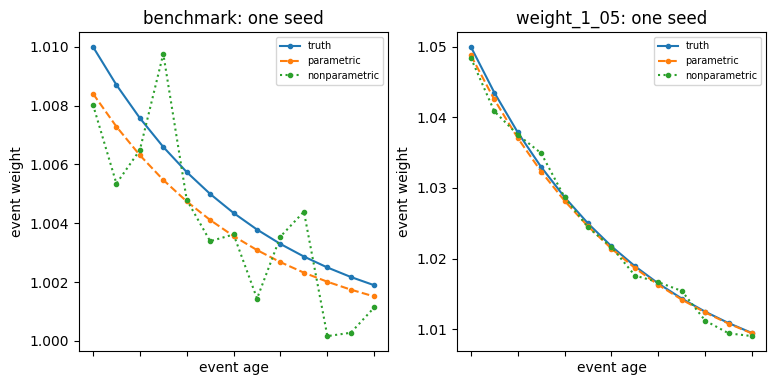

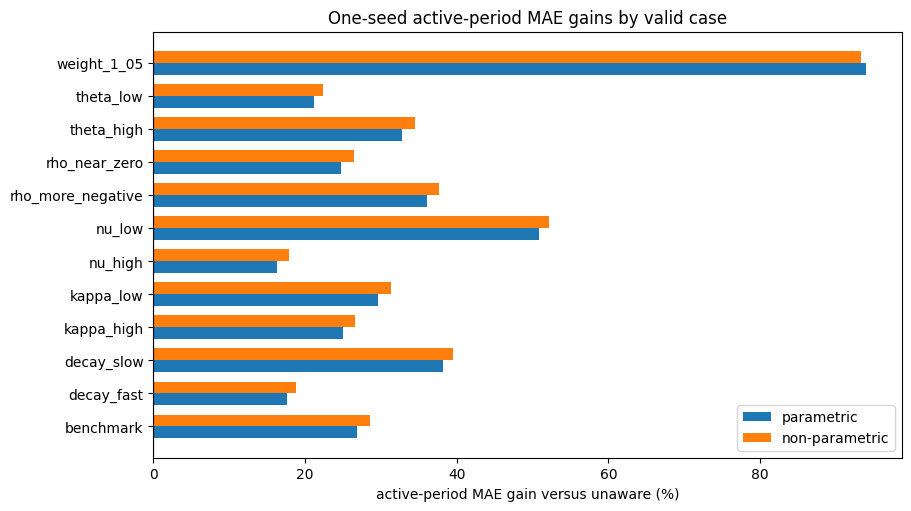

In [17]:
valid_amplitude_cases = [case for case in amplitude_cases if case in set(prototype_profiles.case_name)]
fig, axes = plt.subplots(2, 4, figsize=(14,7), sharex=True, constrained_layout=True)
for axis, case_name in zip(axes.ravel(), valid_amplitude_cases):
    data = prototype_profiles.loc[prototype_profiles.case_name.eq(case_name)]
    for method, style in [('truth','-'),('parametric','--'),('nonparametric',':')]:
        subset = data.loc[data.profile_method.eq(method)]; axis.plot(subset.event_age, subset.event_weight, linestyle=style, marker='o', markersize=3, label=method)
    axis.set(title=f'{case_name}: one seed', xlabel='event age', ylabel='event weight'); axis.legend(fontsize=7)
for axis in axes.ravel()[len(valid_amplitude_cases):]: axis.set_visible(False)
plt.show()
plot_data = prototype_results.loc[prototype_results.run_success].sort_values('case_name'); fig, axis = plt.subplots(figsize=(9,5), constrained_layout=True); y = np.arange(len(plot_data)); width = .36
axis.barh(y-width/2, plot_data['parametric_active_MAE_gain_pct'], height=width, label='parametric'); axis.barh(y+width/2, plot_data['nonparametric_active_MAE_gain_pct'], height=width, label='non-parametric')
axis.axvline(0,color='black',linewidth=.8); axis.set(yticks=y, yticklabels=plot_data.case_name, xlabel='active-period MAE gain versus unaware (%)', title='One-seed active-period MAE gains by valid case'); axis.legend(); plt.show()


## Prototype findings

This section reports only directly observed one-seed implementation status. All successful cases use exactly the same ordered test rows; interval metrics are explicitly labelled as state-space metrics; and the compact run-level table is ready for repeated-seed concatenation. It does not claim robust parameter effects or structural causality from GC or TDMI.

In [18]:
prototype_status = f"Prototype valid pipelines: {prototype_results.run_success.sum()}/{len(case_registry)}. All successful cases share the benchmark's ordered test rows: {successful.common_test_rows.all()}. Profile fits converged on valid paths: {successful.profile_converged.all()}. The revised common-weight cases retain invalid simulations visibly rather than assigning artificial recovery values."
print(prototype_status)

Prototype valid pipelines: 12/17. All successful cases share the benchmark's ordered test rows: True. Profile fits converged on valid paths: True. The revised common-weight cases retain invalid simulations visibly rather than assigning artificial recovery values.


## One-seed prototype checkpoint

The prototype verifies the frozen workflow, compact extraction schema, common-test-row validation, and preliminary figures for each complete valid path. The repeated-seed experiment below supplies robustness and viability evidence without changing the benchmark, non-amplitude cases, estimator, timing, or forecast construction.

## Full 50-seed scalar-parameter experiment

The one-seed prototype established implementation validity but cannot establish statistical robustness. The complete frozen workflow is now repeated over

$$50\text{ seeds}\times17\text{ cases}=850\text{ runs}.$$

For each seed, one independent shock bank is generated; the benchmark is evaluated first; that shock bank is reused for the other 16 scalar cases; and every ordered test-row pair is compared with that seed's benchmark. The next seed uses a new independent shock bank. This provides paired within-seed comparisons while preserving independence across seeds. The design remains a one-at-a-time scalar experiment, not a factorial experiment.

## Execution and output controls

The full experiment is moderately expensive, so compact checkpoint files are overwritten after each completed seed. They protect against losing all progress if execution is interrupted, while a clean rerun from scratch remains possible.

In [19]:
from pathlib import Path
from time import perf_counter

RESULTS_DIR = Path('notebook08_results')
RESULTS_DIR.mkdir(exist_ok=True)
RUN_FULL_REPLICATION = False
RUN_CHECKPOINT_PATH = RESULTS_DIR / 'run_level_checkpoint.csv'
PROFILE_CHECKPOINT_PATH = RESULTS_DIR / 'event_age_profile_checkpoint.csv'
FAILURE_CHECKPOINT_PATH = RESULTS_DIR / 'failure_checkpoint.csv'
assert len(SEEDS) == 50
assert len(case_registry) == 17
assert planned_runs == len(SEEDS) * len(case_registry)
# Set RUN_FULL_REPLICATION=False after the fresh revised-grid run to reload its completed checkpoints.


## Prepare repeated-run storage

Only tidy summaries are retained: one row per seed and case, one row per seed-case-age-profile method, and one row per failed stage with simulation-viability diagnostics if failures occur. Full pipeline result dictionaries are not accumulated.

In [20]:
replication_rows = []
replication_profile_rows = []
replication_failure_rows = []
failure_columns = ['experiment','seed','case_name','parameter','parameter_value','initial_event_weight','failure_stage','exception_type','failure_message','simulation_valid','first_failed_transition','active_event_id_at_failure','active_event_age_at_failure','active_event_weight_at_failure','maximum_volatility_before_failure','minimum_euler_price_update_factor','nonpositive_price_transition']

def write_replication_checkpoints():
    pd.DataFrame(replication_rows).to_csv(RUN_CHECKPOINT_PATH, index=False)
    pd.DataFrame(replication_profile_rows).to_csv(PROFILE_CHECKPOINT_PATH, index=False)
    pd.DataFrame(replication_failure_rows, columns=failure_columns).to_csv(FAILURE_CHECKPOINT_PATH, index=False)


## Execute the repeated scalar cases

The benchmark runs first within every seed. Every high-weight case is attempted with the same seed-specific shocks; invalid simulations are logged at stage `simulation` and do not enter the pipeline.

In [21]:
if RUN_FULL_REPLICATION:
    ordered_registry = pd.concat([case_registry.loc[case_registry.case_name.eq('benchmark')], case_registry.loc[~case_registry.case_name.eq('benchmark')]], ignore_index=True)
    experiment_start = perf_counter()
    for seed_position, seed in enumerate(SEEDS, start=1):
        seed_start = perf_counter(); seed_shock_bank = make_shock_bank(benchmark_case, seed=seed); benchmark_ids_for_seed = None
        for _, registry_row in ordered_registry.iterrows():
            run_start = perf_counter()
            try:
                config = construct_scalar_case(registry_row)
                result = run_full_pipeline(config, shock_bank=seed_shock_bank, **pipeline_options)
                forecast_ids = result['forecasts'][['i', 'target_i']].reset_index(drop=True).copy()
                if registry_row.case_name == 'benchmark': benchmark_ids_for_seed, common_test_rows = forecast_ids, True
                else: common_test_rows = benchmark_ids_for_seed is not None and forecast_ids.equals(benchmark_ids_for_seed)
                summary = summarise_case(result); run_row = extract_run_summary(result, summary, registry_row, seed, common_test_rows)
                run_row.update({'initial_event_weight':registry_row.initial_event_weight,'simulation_valid':True,'first_failed_transition':np.nan,'active_event_id_at_failure':np.nan,'active_event_age_at_failure':np.nan,'active_event_weight_at_failure':np.nan,'maximum_volatility_before_failure':result['simulation']['states']['sigma'].max(),'minimum_euler_price_update_factor':(1 + result['simulation']['states']['sigma'].iloc[:-1].to_numpy() * result['simulation']['transitions']['epsilon'].to_numpy()).min(),'nonpositive_price_transition':False,'run_runtime_seconds':perf_counter()-run_start,'seed_runtime_seconds':np.nan})
                active_truth = result['truth']['table'].loc[result['truth']['table'].event_active_i.eq(1)]; ages = np.arange(13); truth_weight = active_truth.groupby('event_age_i').m_true.mean().reindex(ages); profiles = result['profiles']; case_profile_rows = []
                for method, weights in [('truth',truth_weight),('parametric',pd.Series(profiles['parametric_multiplier'](ages),index=ages)),('nonparametric',profiles['nonparametric'].reindex(ages))]:
                    case_profile_rows.extend({'seed':seed,'case_name':registry_row.case_name,'parameter':registry_row.parameter,'setting':registry_row.setting,'parameter_value':registry_row.parameter_value,'event_age':int(age),'profile_method':method,'event_weight':float(weight ** 2),'volatility_multiplier':float(weight)} for age,weight in weights.items())
                assert common_test_rows and len(truth_weight) == 13 and np.isfinite(truth_weight).all() and len(case_profile_rows) == 39
                replication_rows.append(run_row); replication_profile_rows.extend(case_profile_rows)
            except Exception as exc:
                config = construct_scalar_case(registry_row); diagnostic = diagnose_frozen_simulation(config, seed_shock_bank)
                stage = 'simulation' if not diagnostic['simulation_valid'] else classified_pipeline_stage(exc)
                failure_row = failed_scalar_row(registry_row, seed, stage, exc, diagnostic, perf_counter()-run_start); failure_row['seed_runtime_seconds'] = np.nan
                replication_rows.append(failure_row)
                replication_failure_rows.append({'experiment':'common_weight_scalar' if registry_row.case_name in common_weight_case_names else 'scalar', **{key:failure_row.get(key) for key in failure_columns if key!='experiment'}})
            finally:
                if 'result' in locals(): del result
        seed_elapsed = perf_counter()-seed_start
        for row in replication_rows:
            if row['seed'] == seed: row['seed_runtime_seconds'] = seed_elapsed
        write_replication_checkpoints(); successful_runs = sum(row.get('run_success',False) for row in replication_rows)
        print(f'Completed seed {seed_position}/{len(SEEDS)} | successful runs: {successful_runs}/{len(replication_rows)} | elapsed: {perf_counter()-experiment_start:.1f}s')
    replication_results = pd.DataFrame(replication_rows); replication_profiles = pd.DataFrame(replication_profile_rows); replication_failures = pd.DataFrame(replication_failure_rows, columns=failure_columns)
else:
    required_paths = [RUN_CHECKPOINT_PATH, PROFILE_CHECKPOINT_PATH, FAILURE_CHECKPOINT_PATH]
    missing_paths = [str(path) for path in required_paths if not path.exists()]
    if missing_paths: raise FileNotFoundError(f'Completed replication checkpoints are required: {missing_paths}')
    replication_results = pd.read_csv(RUN_CHECKPOINT_PATH); replication_profiles = pd.read_csv(PROFILE_CHECKPOINT_PATH); replication_failures = pd.read_csv(FAILURE_CHECKPOINT_PATH)


## Finalise and export raw repeated-seed outputs

The raw repeated-seed tables are the primary evidence for Notebook 08. They remain tidy, sorted, and free of duplicated seed-case observations; only compact summaries are exported.

In [22]:
replication_results = replication_results.sort_values(['seed', 'case_name']).reset_index(drop=True)
replication_profiles = replication_profiles.sort_values(['seed', 'case_name', 'profile_method', 'event_age']).reset_index(drop=True)
replication_failures = replication_failures.sort_values(['seed', 'case_name']).reset_index(drop=True)
replication_results.to_csv(RESULTS_DIR / 'notebook08_run_level_results.csv', index=False)
replication_profiles.to_csv(RESULTS_DIR / 'notebook08_event_age_profiles.csv', index=False)
replication_failures.to_csv(RESULTS_DIR / 'notebook08_failures.csv', index=False)
common_weight_failure_log = replication_failures.loc[replication_failures.case_name.isin(common_weight_case_names)].copy()
common_weight_failure_log.to_csv(RESULTS_DIR / 'notebook08_common_weight_failure_log.csv', index=False)


## Validate experiment completeness

The first full-sample checks concern implementation completeness rather than substantive model performance. They verify all intended combinations, paired comparisons, finite metrics, and profile schema integrity.

In [23]:
assert len(replication_results) == planned_runs
assert not replication_results.duplicated(['seed', 'case_name']).any()
assert replication_results.groupby('seed').size().eq(len(case_registry)).all() and replication_results.groupby('case_name').size().eq(len(SEEDS)).all()
successful_replications = replication_results.loc[replication_results.run_success.eq(True)].copy(); successful_run_count = len(successful_replications)
assert successful_replications.common_test_rows.eq(True).all()
assert replication_results.loc[replication_results.case_name.isin(common_weight_case_names) & ~replication_results.simulation_valid.eq(True),'run_success'].eq(False).all()
key_metrics = ['A_hat','lambda_hat','parametric_profile_RMSE','nonparametric_profile_RMSE','baseline_active_sigma_MAE','known_dgp_active_sigma_RMSE']
assert np.isfinite(successful_replications[key_metrics].to_numpy(dtype=float)).all()
coverage_columns = ['parametric_active_95_state_coverage','nonparametric_active_95_state_coverage','known_dgp_active_95_state_coverage']; score_columns = ['parametric_active_95_state_interval_score','nonparametric_active_95_state_interval_score','known_dgp_active_95_state_interval_score']
assert successful_replications[coverage_columns].apply(lambda x:x.between(0,1).all()).all() and (successful_replications[score_columns]>=0).all().all() and successful_replications.profile_converged.eq(True).all()
assert set(replication_profiles.event_age) == set(range(13)) and set(replication_profiles.profile_method) == {'truth','parametric','nonparametric'}
assert not replication_profiles.duplicated(['seed','case_name','event_age','profile_method']).any()
expected_profile_rows = successful_run_count*13*3; assert len(replication_profiles) == expected_profile_rows
experiment_completeness = pd.DataFrame([{'planned_runs':planned_runs,'attempted_runs':len(replication_results),'successful_runs':successful_run_count,'failed_runs':len(replication_results)-successful_run_count,'success_rate':successful_run_count/planned_runs,'planned_seeds':len(SEEDS),'completed_seeds':replication_results.seed.nunique(),'profile_rows':len(replication_profiles)}])
display(experiment_completeness)
if not replication_failures.empty: display(replication_failures)


,planned_runs,attempted_runs,successful_runs,failed_runs,success_rate,planned_seeds,completed_seeds,profile_rows
0,850,850,600,250,0.705882,50,50,23400


,experiment,seed,case_name,parameter,parameter_value,initial_event_weight,failure_stage,exception_type,failure_message,simulation_valid,first_failed_transition,active_event_id_at_failure,active_event_age_at_failure,active_event_weight_at_failure,maximum_volatility_before_failure,minimum_euler_price_update_factor,nonpositive_price_transition
0,common_weight_scalar,20260721,weight_1_10,amplitude,0.1,1.1,simulation,ValueError,S_next is non-positive at transition 365.,False,365,16.0,8.0,1.032919,7.575368,-0.182331,True
1,common_weight_scalar,20260721,weight_1_20,amplitude,0.2,1.2,simulation,ValueError,S_next is non-positive at transition 194.,False,194,8.0,5.0,1.099870,15.786755,-0.326184,True
2,common_weight_scalar,20260721,weight_1_30,amplitude,0.3,1.3,simulation,ValueError,S_next is non-positive at transition 115.,False,115,4.0,10.0,1.074806,9.756149,-0.045055,True
3,common_weight_scalar,20260721,weight_1_40,amplitude,0.4,1.4,simulation,ValueError,S_next is non-positive at transition 95.,False,95,3.0,11.0,1.086807,12.901143,-0.141379,True
4,common_weight_scalar,20260721,weight_1_50,amplitude,0.5,1.5,simulation,ValueError,S_next is non-positive at transition 78.,False,78,NaN,NaN,NaN,10.331261,-0.248236,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,common_weight_scalar,20260770,weight_1_10,amplitude,0.1,1.1,simulation,ValueError,S_next is non-positive at transition 382.,False,382,17.0,4.0,1.057375,8.695331,-0.207552,True
246,common_weight_scalar,20260770,weight_1_20,amplitude,0.2,1.2,simulation,ValueError,S_next is non-positive at transition 193.,False,193,8.0,4.0,1.114751,15.123951,-0.682194,True
247,common_weight_scalar,20260770,weight_1_30,amplitude,0.3,1.3,simulation,ValueError,S_next is non-positive at transition 114.,False,114,4.0,9.0,1.085951,9.492609,-0.107983,True
248,common_weight_scalar,20260770,weight_1_40,amplitude,0.4,1.4,simulation,ValueError,S_next is non-positive at transition 113.,False,113,4.0,8.0,1.131677,31.536950,-0.980633,True


## Define repeated-seed derived metrics

Detection indicators, timing recovery, forecast improvements, calibration error, and fitted-to-Known-DGP gaps are derived from stored run-level metrics only. No model is rerun for these transformations.

In [24]:
analysis_results = replication_results.copy(); success_mask = analysis_results.run_success.eq(True)
analysis_results['gc_level_detected_5pct'] = np.where(success_mask, analysis_results.gc_level_p_value < .05, np.nan)
analysis_results['gc_change_detected_5pct'] = np.where(success_mask, analysis_results.gc_change_p_value < .05, np.nan)
analysis_results['tdmi_change_peak_at_plus_1'] = np.where(success_mask, analysis_results.tdmi_change_direct_peak_lag.eq(1), np.nan)
analysis_results['tdmi_level_peak_in_direct_window'] = np.where(success_mask, analysis_results.tdmi_level_direct_peak_lag.between(1, 13), np.nan)
for model in ['parametric', 'nonparametric', 'known_dgp']:
    coverage = f'{model}_active_95_state_coverage'
    if coverage in analysis_results: analysis_results[f'{model}_95_state_coverage_error'] = (analysis_results[coverage] - .95).abs()
analysis_results['parametric_known_dgp_active_RMSE_gap'] = analysis_results.parametric_active_sigma_RMSE - analysis_results.known_dgp_active_sigma_RMSE
analysis_results['nonparametric_known_dgp_active_RMSE_gap'] = analysis_results.nonparametric_active_sigma_RMSE - analysis_results.known_dgp_active_sigma_RMSE
analysis_results['parametric_positive_MAE_gain'] = np.where(success_mask, analysis_results.parametric_active_MAE_gain_pct > 0, np.nan)
analysis_results['nonparametric_positive_MAE_gain'] = np.where(success_mask, analysis_results.nonparametric_active_MAE_gain_pct > 0, np.nan)

## Statistical summary helpers

Numeric metrics and binary detection rates require different uncertainty summaries. Means use standard errors and 95% Student-$t$ intervals, binary rates use 95% Wilson intervals, and empirical quantiles show distribution shape. These intervals quantify Monte Carlo variation over 50 simulated shock realisations, not uncertainty about real financial-market parameters.

In [25]:
from scipy.stats import t, norm

def summarise_numeric_series(series):
    values = pd.to_numeric(series, errors='coerce').dropna().to_numpy(dtype=float); count = len(values)
    mean = float(np.mean(values)) if count else np.nan; sd = float(np.std(values, ddof=1)) if count > 1 else np.nan
    se = sd / np.sqrt(count) if count > 1 else np.nan; critical = t.ppf(.975, count - 1) if count > 1 else np.nan
    return {'count': count, 'mean': mean, 'standard_deviation': sd, 'monte_carlo_standard_error': se, 'ci_95_lower': mean - critical * se if count > 1 else np.nan, 'ci_95_upper': mean + critical * se if count > 1 else np.nan, 'median': float(np.median(values)) if count else np.nan, 'q05': float(np.quantile(values, .05)) if count else np.nan, 'q25': float(np.quantile(values, .25)) if count else np.nan, 'q75': float(np.quantile(values, .75)) if count else np.nan, 'q95': float(np.quantile(values, .95)) if count else np.nan}

def wilson_interval(successes, count):
    if count == 0: return np.nan, np.nan
    z, rate = norm.ppf(.975), successes / count; denominator = 1 + z ** 2 / count
    centre = (rate + z ** 2 / (2 * count)) / denominator; radius = z * np.sqrt(rate * (1 - rate) / count + z ** 2 / (4 * count ** 2)) / denominator
    return centre - radius, centre + radius

def summarise_binary_series(series):
    values = pd.Series(series).dropna().astype(bool); count, successes = len(values), int(values.sum()); lower, upper = wilson_interval(successes, count)
    return {'count': count, 'successes': successes, 'rate': successes / count if count else np.nan, 'ci_95_lower': lower, 'ci_95_upper': upper}

## Build the case-level numeric summary

Each scalar case is summarised over its 50 independent seeds. The benchmark remains one underlying case rather than being duplicated across parameter families.

In [26]:
numeric_metrics = ['conditional_partial_r_squared', 'gc_level_partial_r_squared', 'gc_change_partial_r_squared', 'tdmi_level_direct_peak', 'tdmi_change_direct_peak', 'A_hat', 'A_relative_error', 'lambda_hat', 'lambda_relative_error', 'parametric_profile_MAE', 'parametric_profile_RMSE', 'nonparametric_profile_MAE', 'nonparametric_profile_RMSE', 'parametric_active_MAE_gain_pct', 'parametric_active_RMSE_gain_pct', 'nonparametric_active_MAE_gain_pct', 'nonparametric_active_RMSE_gain_pct', 'known_dgp_active_sigma_RMSE', 'parametric_known_dgp_active_RMSE_gap', 'nonparametric_known_dgp_active_RMSE_gap', 'parametric_active_95_state_coverage', 'parametric_95_state_coverage_error', 'parametric_active_95_state_interval_score', 'nonparametric_active_95_state_coverage', 'nonparametric_95_state_coverage_error', 'nonparametric_active_95_state_interval_score', 'known_dgp_active_95_state_coverage', 'known_dgp_95_state_coverage_error', 'known_dgp_active_95_state_interval_score']
summary_keys = ['case_name', 'parameter', 'setting', 'parameter_value']; numeric_rows = []
for key_values, group in analysis_results.loc[success_mask].groupby(summary_keys, dropna=False):
    key_data = dict(zip(summary_keys, key_values))
    for metric in numeric_metrics: numeric_rows.append({**key_data, 'metric': metric, **summarise_numeric_series(group[metric])})
numeric_summary = pd.DataFrame(numeric_rows)
numeric_summary.to_csv(RESULTS_DIR / 'notebook08_numeric_summary.csv', index=False)

## Build the detection-rate summary

Rejection frequency alone is insufficient and must be read with numeric partial-$R^2$ and TDMI summaries. This table reports binary frequencies with Wilson intervals.

In [27]:
detection_metrics = ['gc_level_detected_5pct', 'gc_change_detected_5pct', 'tdmi_change_peak_at_plus_1', 'tdmi_level_peak_in_direct_window', 'parametric_positive_MAE_gain', 'nonparametric_positive_MAE_gain']; detection_rows = []
for key_values, group in analysis_results.loc[success_mask].groupby(summary_keys, dropna=False):
    key_data = dict(zip(summary_keys, key_values))
    for metric in detection_metrics: detection_rows.append({**key_data, 'metric': metric, **summarise_binary_series(group[metric])})
detection_summary = pd.DataFrame(detection_rows)
detection_summary.to_csv(RESULTS_DIR / 'notebook08_detection_summary.csv', index=False)

## Build paired benchmark contrasts

Common shocks allow every non-benchmark run to be compared directly with the same-seed benchmark:

$$D_{s,c}=M_{s,c}-M_{s,\mathrm{benchmark}}.$$

Higher forecast gain is better; lower profile RMSE, coverage error, interval score, and Known-DGP RMSE gap are better. The sign is therefore interpreted in the context of the metric.

In [28]:
paired_metrics = ['conditional_partial_r_squared', 'parametric_profile_RMSE', 'nonparametric_profile_RMSE', 'parametric_active_MAE_gain_pct', 'nonparametric_active_MAE_gain_pct', 'parametric_active_RMSE_gain_pct', 'nonparametric_active_RMSE_gain_pct', 'parametric_95_state_coverage_error', 'nonparametric_95_state_coverage_error', 'parametric_active_95_state_interval_score', 'nonparametric_active_95_state_interval_score', 'parametric_known_dgp_active_RMSE_gap', 'nonparametric_known_dgp_active_RMSE_gap']
paired_source = analysis_results.loc[success_mask].copy(); benchmark_by_seed = paired_source.loc[paired_source.case_name.eq('benchmark'), ['seed'] + paired_metrics].set_index('seed'); paired_rows = []
for _, case_row in paired_source.loc[~paired_source.case_name.eq('benchmark')].iterrows():
    benchmark_row = benchmark_by_seed.loc[case_row.seed]
    for metric in paired_metrics:
        paired_rows.append({'seed': case_row.seed, 'case_name': case_row.case_name, 'parameter': case_row.parameter, 'setting': case_row.setting, 'parameter_value': case_row.parameter_value, 'metric': metric, 'case_value': case_row[metric], 'benchmark_value': benchmark_row[metric], 'paired_difference': case_row[metric] - benchmark_row[metric]})
paired_contrasts_raw = pd.DataFrame(paired_rows); paired_summary_rows = []
for key_values, group in paired_contrasts_raw.groupby(summary_keys + ['metric'], dropna=False):
    key_data, stats = dict(zip(summary_keys + ['metric'], key_values)), summarise_numeric_series(group.paired_difference)
    paired_summary_rows.append({**key_data, 'count': stats['count'], 'mean_difference': stats['mean'], 'standard_deviation': stats['standard_deviation'], 'monte_carlo_standard_error': stats['monte_carlo_standard_error'], 'ci_95_lower': stats['ci_95_lower'], 'ci_95_upper': stats['ci_95_upper'], 'median_difference': stats['median'], 'q05': stats['q05'], 'q25': stats['q25'], 'q75': stats['q75'], 'q95': stats['q95']})
paired_contrast_summary = pd.DataFrame(paired_summary_rows)
paired_contrasts_raw.to_csv(RESULTS_DIR / 'notebook08_paired_contrasts_raw.csv', index=False)
paired_contrast_summary.to_csv(RESULTS_DIR / 'notebook08_paired_contrast_summary.csv', index=False)

## Aggregate event-age profiles

Amplitude and decay estimates can compensate for one another, so recovery of the complete fitted event profile is assessed across seeds. Each case-method-age distribution retains central tendency and spread.

In [29]:
profile_keys = ['case_name', 'parameter', 'setting', 'parameter_value', 'profile_method', 'event_age']
profile_long = replication_profiles.melt(id_vars=profile_keys, value_vars=['event_weight', 'volatility_multiplier'], var_name='profile_quantity', value_name='value')
profile_summary = profile_long.groupby(profile_keys + ['profile_quantity'], dropna=False)['value'].agg(count='count', mean='mean', median='median', q05=lambda x: x.quantile(.05), q25=lambda x: x.quantile(.25), q75=lambda x: x.quantile(.75), q95=lambda x: x.quantile(.95)).reset_index()
expected_profile_counts = successful_replications.groupby('case_name').size()
for case_name, count in expected_profile_counts.items(): assert profile_summary.loc[profile_summary.case_name.eq(case_name), 'count'].eq(count).all()
profile_summary.to_csv(RESULTS_DIR / 'notebook08_profile_summary.csv', index=False)

## Display compact aggregate tables

Only decision-relevant summaries are displayed here; complete tidy raw and summary tables are available as CSV exports.

In [30]:
display(experiment_completeness[['planned_runs','successful_runs','failed_runs','success_rate']])
display(detection_summary.loc[detection_summary.metric.isin(['gc_change_detected_5pct','tdmi_change_peak_at_plus_1']), ['case_name','parameter_value','metric','rate','ci_95_lower','ci_95_upper']])
median_metrics = ['parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct']
forecast_display = numeric_summary.loc[numeric_summary.metric.isin(median_metrics), ['case_name','parameter_value','metric','median']].pivot(index=['case_name','parameter_value'],columns='metric',values='median').reset_index().rename(columns={'parametric_active_MAE_gain_pct':'median_parametric_active_MAE_gain_pct','nonparametric_active_MAE_gain_pct':'median_nonparametric_active_MAE_gain_pct'})
mean_metrics = ['parametric_active_95_state_coverage','parametric_active_95_state_interval_score']
forecast_means = numeric_summary.loc[numeric_summary.metric.isin(mean_metrics), ['case_name','metric','mean']].pivot(index='case_name',columns='metric',values='mean').reset_index().rename(columns={'parametric_active_95_state_coverage':'mean_parametric_95_state_coverage','parametric_active_95_state_interval_score':'mean_parametric_95_state_interval_score'})
gain_rates = detection_summary.loc[detection_summary.metric.isin(['parametric_positive_MAE_gain','nonparametric_positive_MAE_gain']), ['case_name','metric','rate']].pivot(index='case_name',columns='metric',values='rate').reset_index().rename(columns={'parametric_positive_MAE_gain':'parametric_positive_gain_rate','nonparametric_positive_MAE_gain':'nonparametric_positive_gain_rate'})
forecast_display = forecast_display.merge(gain_rates,on='case_name').merge(forecast_means,on='case_name')
display(forecast_display)
recovery_metrics = ['A_relative_error','lambda_relative_error','parametric_profile_RMSE','nonparametric_profile_RMSE']
recovery_display = numeric_summary.loc[numeric_summary.metric.isin(recovery_metrics), ['case_name','metric','median']].pivot(index='case_name',columns='metric',values='median').reset_index()
display(recovery_display)

# Revised amplitude output: survival is primary; recovery is conditional on complete valid paths.
common_runs = replication_results.loc[replication_results.case_name.isin(common_weight_case_names)].copy()
common_weight_survival = common_runs.groupby(['case_name','initial_event_weight','parameter_value'],dropna=False).agg(
    attempted_runs=('seed','size'), valid_path_count=('simulation_valid','sum'), successful_pipeline_count=('run_success','sum'),
    mean_maximum_volatility_before_failure=('maximum_volatility_before_failure','mean'), minimum_euler_price_update_factor=('minimum_euler_price_update_factor','min'),
    nonpositive_price_failures=('nonpositive_price_transition','sum')
).reset_index()
common_weight_survival['invalid_path_count'] = common_weight_survival.attempted_runs-common_weight_survival.valid_path_count
common_weight_survival['survival_proportion'] = common_weight_survival.valid_path_count/common_weight_survival.attempted_runs
common_weight_survival['simulation_failures'] = common_weight_survival.invalid_path_count
common_weight_survival['fitting_failures_after_valid_simulation'] = common_weight_survival.valid_path_count-common_weight_survival.successful_pipeline_count
common_weight_survival['convergence_warnings'] = common_weight_survival.case_name.map(common_runs.loc[common_runs.run_success.eq(True)].groupby('case_name')['profile_converged'].apply(lambda x:int(x.eq(False).sum()))).fillna(0).astype(int)
valid_common = common_runs.loc[common_runs.run_success.eq(True)].copy()
if not valid_common.empty:
    valid_common['weight_true'] = valid_common.initial_event_weight; valid_common['weight_hat'] = 1 + valid_common.A_hat
    valid_common['weight_error'] = valid_common.weight_hat-valid_common.weight_true; valid_common['decay_error'] = valid_common.lambda_hat-valid_common.lambda_true
    common_weight_recovery = valid_common.groupby(['case_name','initial_event_weight','parameter_value'],dropna=False).agg(
        valid_complete_paths=('seed','size'), weight_bias=('weight_error','mean'), weight_MAE=('weight_error',lambda x:np.mean(np.abs(x))), weight_RMSE=('weight_error',lambda x:np.sqrt(np.mean(np.square(x)))),
        decay_bias=('decay_error','mean'), decay_MAE=('decay_error',lambda x:np.mean(np.abs(x))), decay_RMSE=('decay_error',lambda x:np.sqrt(np.mean(np.square(x)))),
        active_period_forecast_MAE=('parametric_active_sigma_MAE','mean'), active_period_forecast_RMSE=('parametric_active_sigma_RMSE','mean'), forecast_improvement_over_no_event_pct=('parametric_active_MAE_gain_pct','mean'),
        calibration_95_coverage=('parametric_active_95_state_coverage','mean'), calibration_interval_score=('parametric_active_95_state_interval_score','mean'),
        gc_change_partial_r_squared=('gc_change_partial_r_squared','mean'), tdmi_change_direct_peak=('tdmi_change_direct_peak','mean')
    ).reset_index()
else:
    common_weight_recovery = common_weight_survival[['case_name','initial_event_weight','parameter_value']].copy()
    for column in ['valid_complete_paths','weight_bias','weight_MAE','weight_RMSE','decay_bias','decay_MAE','decay_RMSE','active_period_forecast_MAE','active_period_forecast_RMSE','forecast_improvement_over_no_event_pct','calibration_95_coverage','calibration_interval_score','gc_change_partial_r_squared','tdmi_change_direct_peak']: common_weight_recovery[column]=np.nan
common_weight_failure_stage_counts = common_weight_failure_log.groupby('failure_stage',dropna=False).size().rename('failure_count').reset_index()
common_weight_survival.to_csv(RESULTS_DIR/'notebook08_common_weight_survival.csv',index=False)
common_weight_recovery.to_csv(RESULTS_DIR/'notebook08_common_weight_valid_path_recovery.csv',index=False)
display(common_weight_survival.sort_values('initial_event_weight'))
display(common_weight_recovery.sort_values('initial_event_weight'))
display(common_weight_failure_stage_counts)


,planned_runs,successful_runs,failed_runs,success_rate
0,850,600,250,0.705882


,case_name,parameter_value,metric,rate,ci_95_lower,ci_95_upper
1,benchmark,NaN,gc_change_detected_5pct,1.00,0.928652,1.000000
2,benchmark,NaN,tdmi_change_peak_at_plus_1,0.46,0.329697,0.596011
7,decay_fast,70.0000,gc_change_detected_5pct,1.00,0.928652,1.000000
8,decay_fast,70.0000,tdmi_change_peak_at_plus_1,0.72,0.583349,0.825258
13,decay_slow,17.5000,gc_change_detected_5pct,1.00,0.928652,1.000000
14,decay_slow,17.5000,tdmi_change_peak_at_plus_1,0.26,0.158715,0.395532
19,kappa_high,3.0000,gc_change_detected_5pct,1.00,0.928652,1.000000
20,kappa_high,3.0000,tdmi_change_peak_at_plus_1,0.46,0.329697,0.596011
25,kappa_low,0.7500,gc_change_detected_5pct,1.00,0.928652,1.000000
26,kappa_low,0.7500,tdmi_change_peak_at_plus_1,0.52,0.385117,0.652029


metric,case_name,parameter_value,median_nonparametric_active_MAE_gain_pct,median_parametric_active_MAE_gain_pct,nonparametric_positive_gain_rate,parametric_positive_gain_rate,mean_parametric_95_state_coverage,mean_parametric_95_state_interval_score
0,benchmark,NaN,22.038878,22.416529,0.98,1.00,0.944615,0.004199
1,decay_fast,70.0000,10.925671,12.436137,0.92,0.98,0.940000,0.004194
2,decay_slow,17.5000,34.898813,36.150070,1.00,1.00,0.945275,0.004213
3,kappa_high,3.0000,16.441667,19.006190,0.98,1.00,0.941978,0.004168
4,kappa_low,0.7500,25.527102,27.545629,0.98,1.00,0.943516,0.004240
5,nu_high,0.0225,9.594169,12.363473,0.92,0.96,0.942198,0.006304
6,nu_low,0.0075,47.666760,49.255709,1.00,1.00,0.945055,0.002101
7,rho_more_negative,-0.7000,31.184967,31.835285,1.00,1.00,0.945495,0.003198
8,rho_near_zero,-0.0500,19.747153,20.566886,0.98,0.98,0.944396,0.004481
9,theta_high,0.2500,28.260788,28.549553,0.98,1.00,0.945495,0.004212


metric,case_name,A_relative_error,lambda_relative_error,nonparametric_profile_RMSE,parametric_profile_RMSE
0,benchmark,-0.007860,0.001962,0.001028,0.000425
1,decay_fast,-0.017358,-0.010845,0.001091,0.000473
2,decay_slow,0.006207,0.010059,0.000978,0.000429
3,kappa_high,-0.012934,-0.012372,0.001097,0.000466
4,kappa_low,-0.006776,0.006223,0.000990,0.000404
5,nu_high,-0.012795,0.002481,0.001544,0.000643
6,nu_low,-0.002545,0.000267,0.000517,0.000219
7,rho_more_negative,-0.006597,-0.004341,0.000785,0.000322
8,rho_near_zero,-0.007452,-0.003008,0.001094,0.000461
9,theta_high,-0.004028,0.001830,0.000911,0.000374


,case_name,initial_event_weight,parameter_value,attempted_runs,valid_path_count,successful_pipeline_count,mean_maximum_volatility_before_failure,minimum_euler_price_update_factor,nonpositive_price_failures,invalid_path_count,survival_proportion,simulation_failures,fitting_failures_after_valid_simulation,convergence_warnings
0,weight_1_05,1.05,0.05,50,50,50,1.322124,0.707145,0,0,1.0,0,0,0
1,weight_1_10,1.10,0.10,50,0,0,8.743660,-0.585770,50,50,0.0,50,0,0
2,weight_1_20,1.20,0.20,50,0,0,10.874221,-1.009463,50,50,0.0,50,0,0
3,weight_1_30,1.30,0.30,50,0,0,11.907209,-2.805929,50,50,0.0,50,0,0
4,weight_1_40,1.40,0.40,50,0,0,13.760527,-2.193037,50,50,0.0,50,0,0
5,weight_1_50,1.50,0.50,50,0,0,15.718398,-3.436953,50,50,0.0,50,0,0


,case_name,initial_event_weight,parameter_value,valid_complete_paths,weight_bias,weight_MAE,weight_RMSE,decay_bias,decay_MAE,decay_RMSE,active_period_forecast_MAE,active_period_forecast_RMSE,forecast_improvement_over_no_event_pct,calibration_95_coverage,calibration_interval_score,gc_change_partial_r_squared,tdmi_change_direct_peak
0,weight_1_05,1.05,0.05,50,0.00009,0.000836,0.001037,-0.100521,0.886179,1.134842,0.00078,0.000972,94.084528,0.925055,0.004683,0.715804,0.070871


,failure_stage,failure_count
0,simulation,250


## Create plot ordering metadata

Plots follow scientific parameter order rather than alphabetical case-name order. The benchmark is retained once in raw tables but may appear in each family view for comparison.

In [31]:
family_order = ['kappa', 'theta', 'nu', 'rho', 'amplitude', 'decay_rate']
family_case_order = {'kappa':['kappa_low','benchmark','kappa_high'],'theta':['theta_low','benchmark','theta_high'],'nu':['nu_low','benchmark','nu_high'],'rho':['rho_more_negative','benchmark','rho_near_zero'],'amplitude':['benchmark']+common_weight_case_names,'decay_rate':['decay_slow','benchmark','decay_fast']}
plot_case_order = []
for family in family_order: plot_case_order.extend(case for case in family_case_order[family] if case not in plot_case_order)
assert set(plot_case_order) == set(case_registry.case_name)


def plot_values(case_name, metric):
    values = analysis_results.loc[success_mask & analysis_results.case_name.eq(case_name), metric].dropna().to_numpy()
    return values if len(values) else np.array([np.nan])


## Figure 1 — Detection robustness

Event detection is evaluated across shock realisations. Rates are shown with Wilson uncertainty and do not imply structural causality.

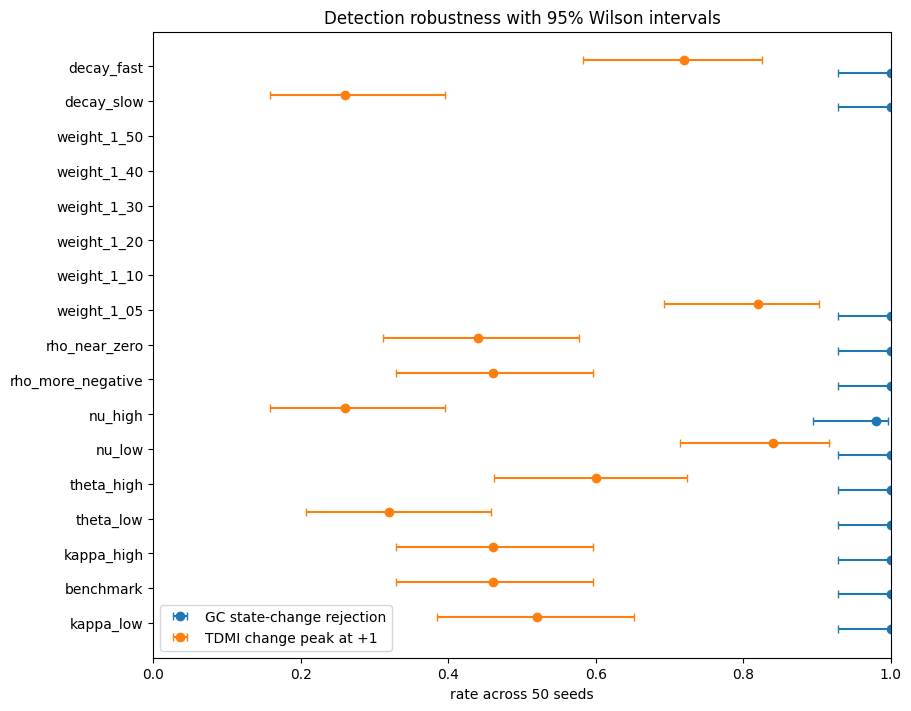

In [32]:
final_figures = {}
detection_plot = detection_summary.loc[detection_summary.metric.isin(['gc_change_detected_5pct', 'tdmi_change_peak_at_plus_1'])].pivot(index='case_name', columns='metric', values=['rate', 'ci_95_lower', 'ci_95_upper']).reindex(plot_case_order)
fig, axis = plt.subplots(figsize=(9, 7), constrained_layout=True); y = np.arange(len(plot_case_order))
for offset, metric, label in zip([-.18, .18], ['gc_change_detected_5pct', 'tdmi_change_peak_at_plus_1'], ['GC state-change rejection', 'TDMI change peak at +1']):
    rate, lower, upper = (detection_plot[(field, metric)].to_numpy() for field in ['rate', 'ci_95_lower', 'ci_95_upper'])
    axis.errorbar(rate, y + offset, xerr=np.vstack([rate - lower, upper - rate]), fmt='o', capsize=3, label=label)
axis.set(yticks=y, yticklabels=plot_case_order, xlim=(0, 1), xlabel='rate across 50 seeds', title='Detection robustness with 95% Wilson intervals'); axis.legend()
final_figures['detection_robustness.png'] = fig
plt.show()

## Figure 2 — Event-profile recovery

Profile RMSE evaluates recovery of the complete event-response shape, which is more informative than considering $\widehat A$ or $\widehat\lambda$ separately.

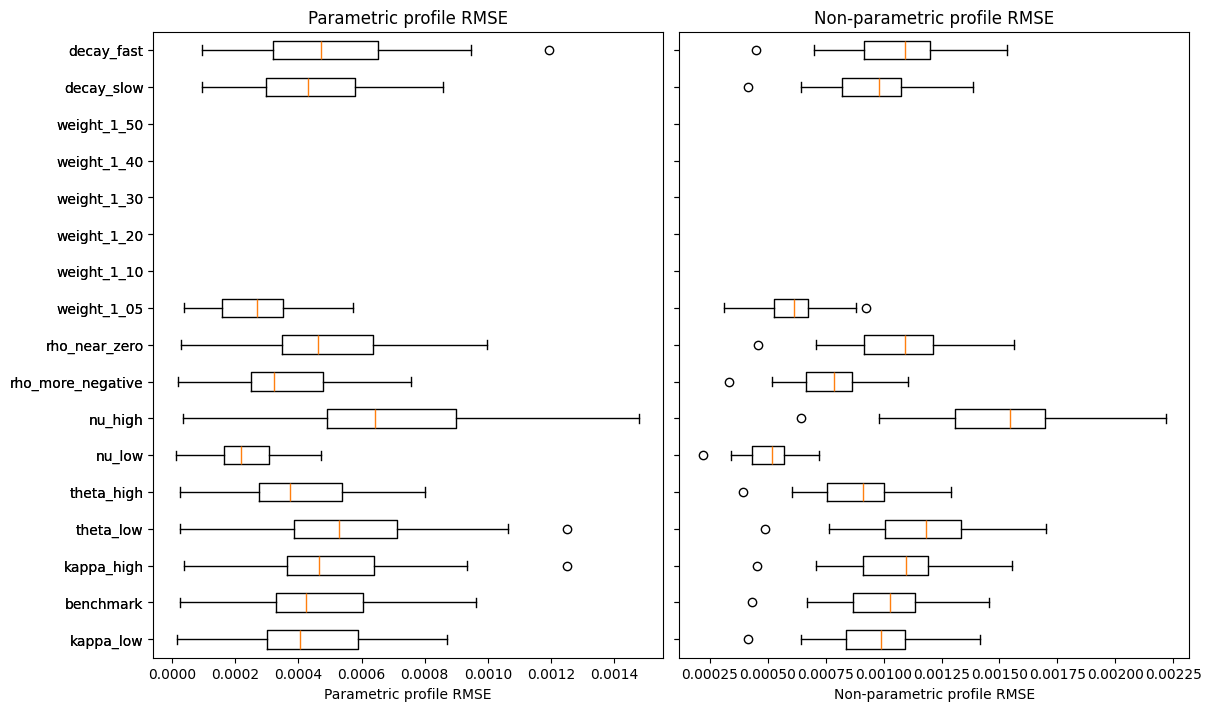

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True, constrained_layout=True)
for axis, metric, label in zip(axes, ['parametric_profile_RMSE', 'nonparametric_profile_RMSE'], ['Parametric profile RMSE', 'Non-parametric profile RMSE']):
    data = [plot_values(case, metric) for case in plot_case_order]
    axis.boxplot(data, vert=False, tick_labels=plot_case_order, showfliers=True); axis.set(xlabel=label, title=label)
final_figures['profile_rmse.png'] = fig
plt.show()

## Figure 3 — Forecast gains

Positive gain means an event-aware forecast improves on the event-unaware baseline during active event periods. The distribution across seeds is more informative than a single average, and negative outcomes are retained.

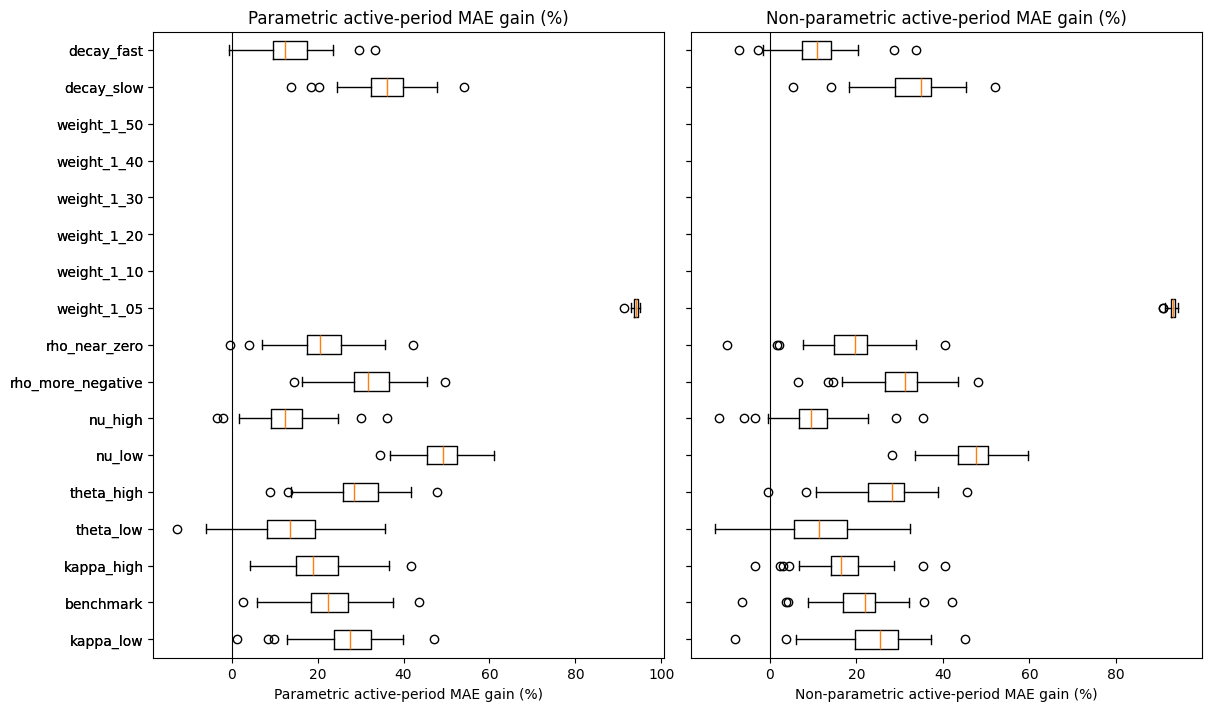

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True, constrained_layout=True)
for axis, metric, label in zip(axes, ['parametric_active_MAE_gain_pct', 'nonparametric_active_MAE_gain_pct'], ['Parametric active-period MAE gain (%)', 'Non-parametric active-period MAE gain (%)']):
    data = [plot_values(case, metric) for case in plot_case_order]
    axis.boxplot(data, vert=False, tick_labels=plot_case_order, showfliers=True); axis.axvline(0, color='black', linewidth=.8); axis.set(xlabel=label, title=label)
final_figures['forecast_mae_gains.png'] = fig
plt.show()

## Figure 4 — Calibration

Coverage should be close to 95%, but coverage alone can improve artificially through excessively wide intervals. Coverage error and interval score are therefore shown separately.

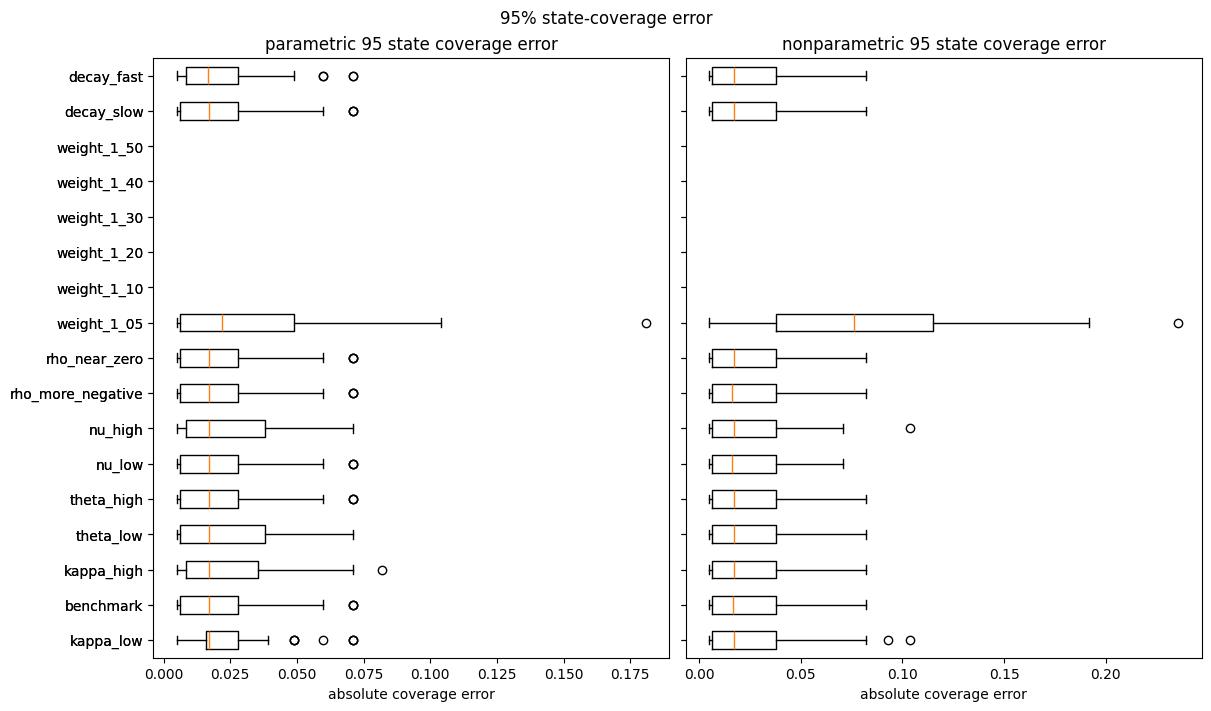

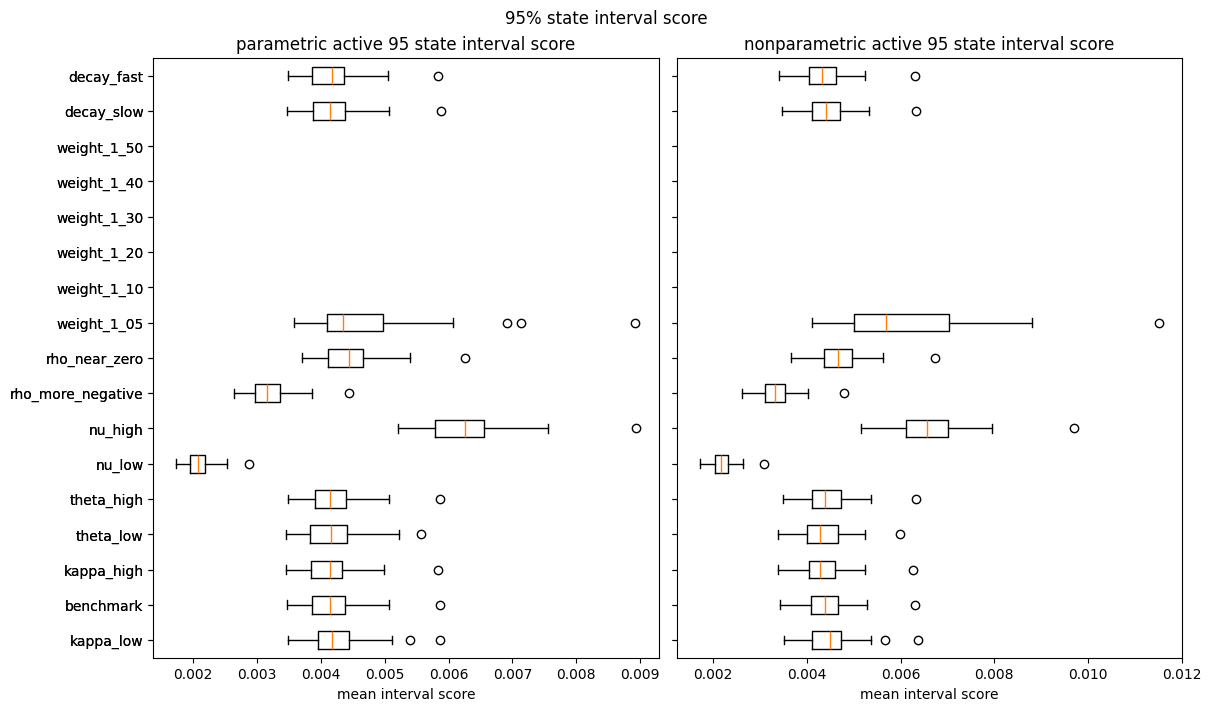

In [35]:
for filename, metrics, title, xlabel in [('coverage_error.png', ['parametric_95_state_coverage_error', 'nonparametric_95_state_coverage_error'], '95% state-coverage error', 'absolute coverage error'), ('interval_scores.png', ['parametric_active_95_state_interval_score', 'nonparametric_active_95_state_interval_score'], '95% state interval score', 'mean interval score')]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True, constrained_layout=True)
    for axis, metric in zip(axes, metrics):
        data = [plot_values(case, metric) for case in plot_case_order]
        axis.boxplot(data, vert=False, tick_labels=plot_case_order, showfliers=True); axis.set(xlabel=xlabel, title=metric.replace('_', ' '))
    fig.suptitle(title); final_figures[filename] = fig; plt.show()

## Figure 5 — Mean event profiles by parameter family

Each family view shows how the fitted response changes when one scalar parameter varies and all others remain fixed. Truth is used only as an evaluation reference; fitted methods retain 5th–95th percentile bands.

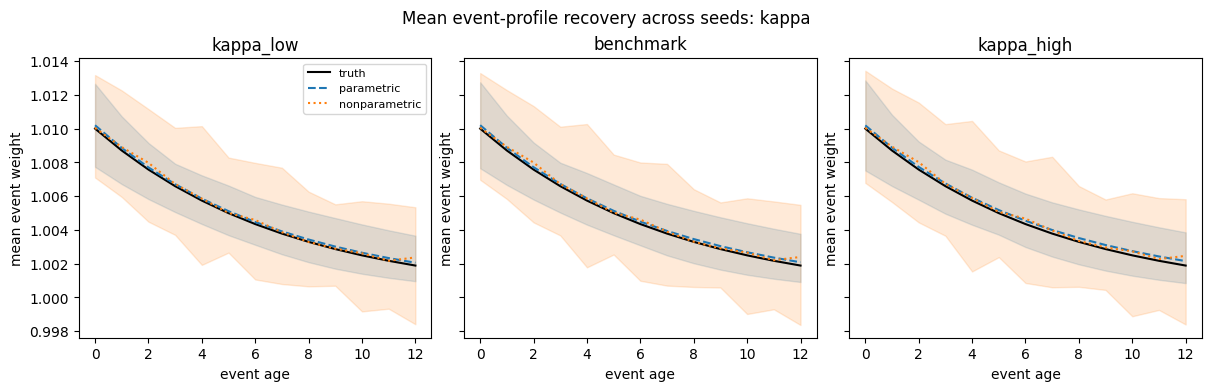

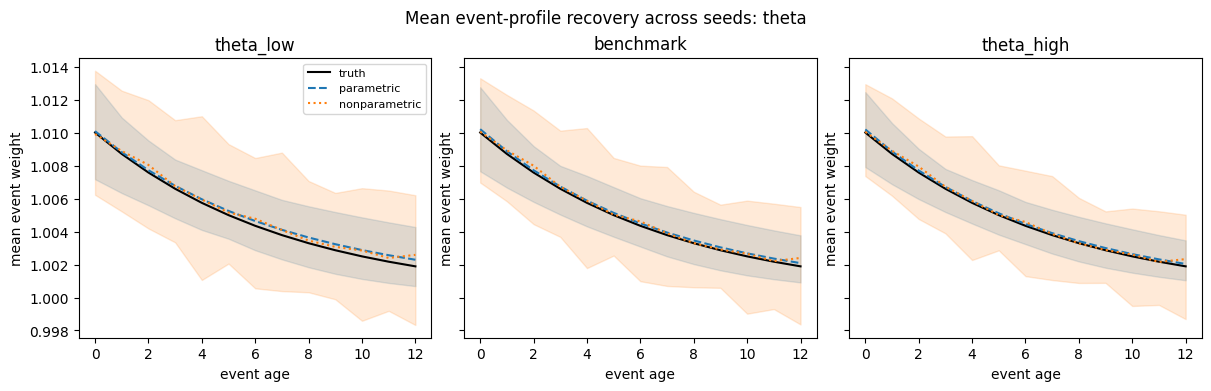

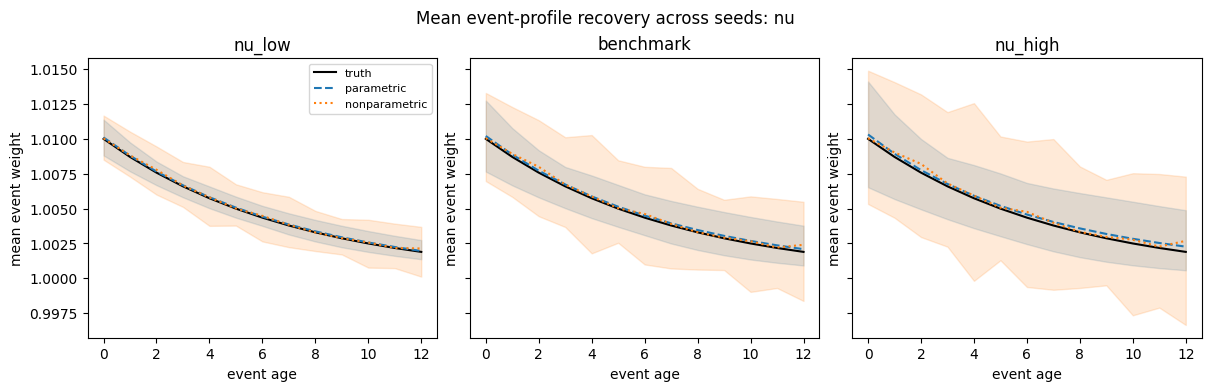

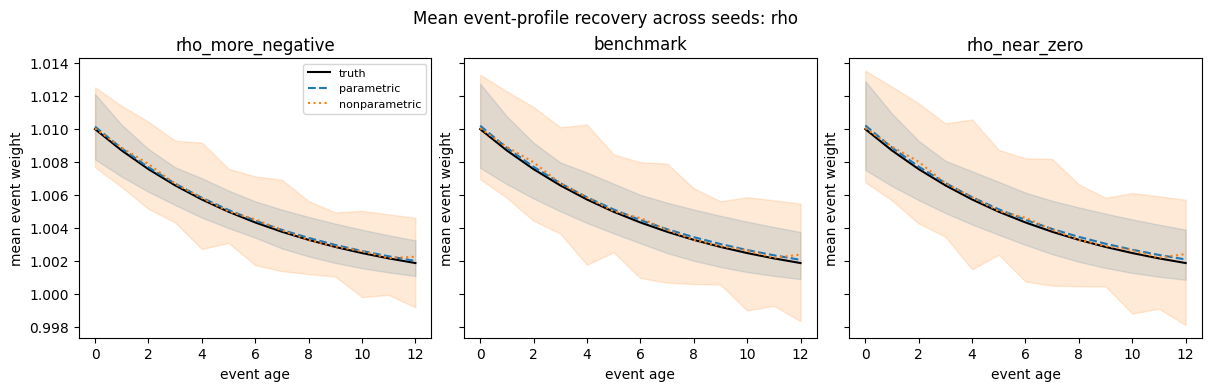

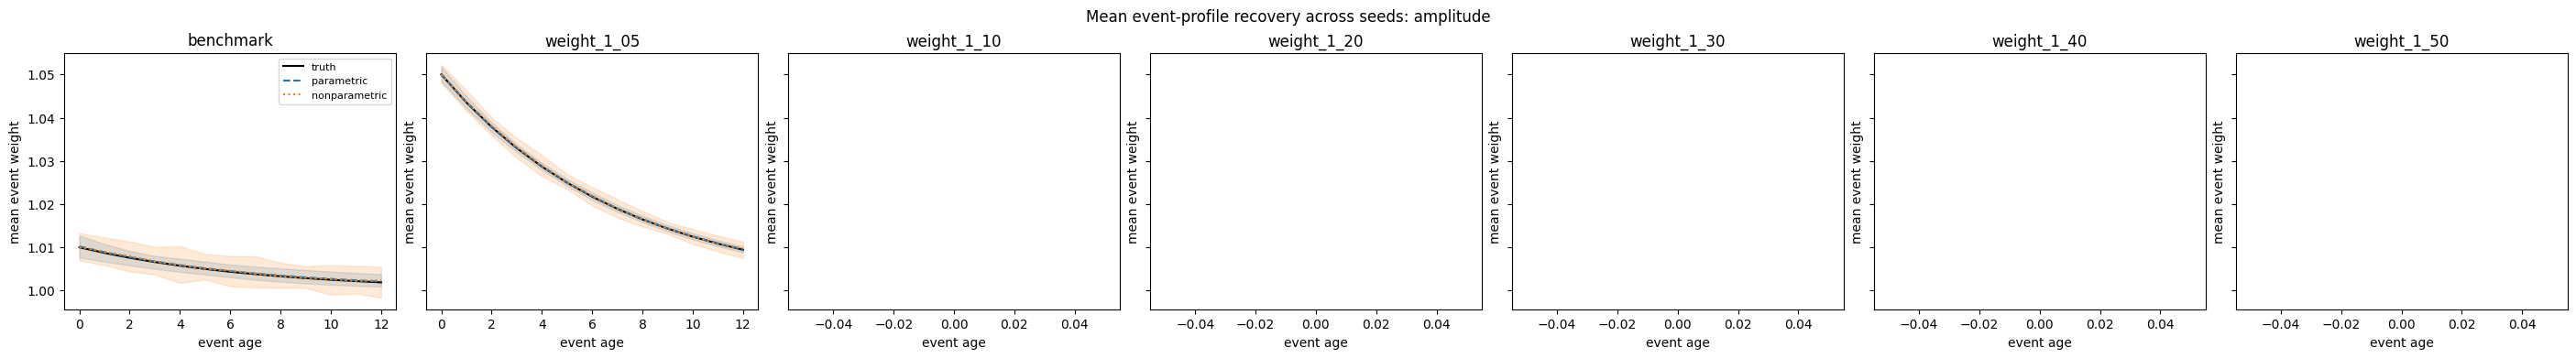

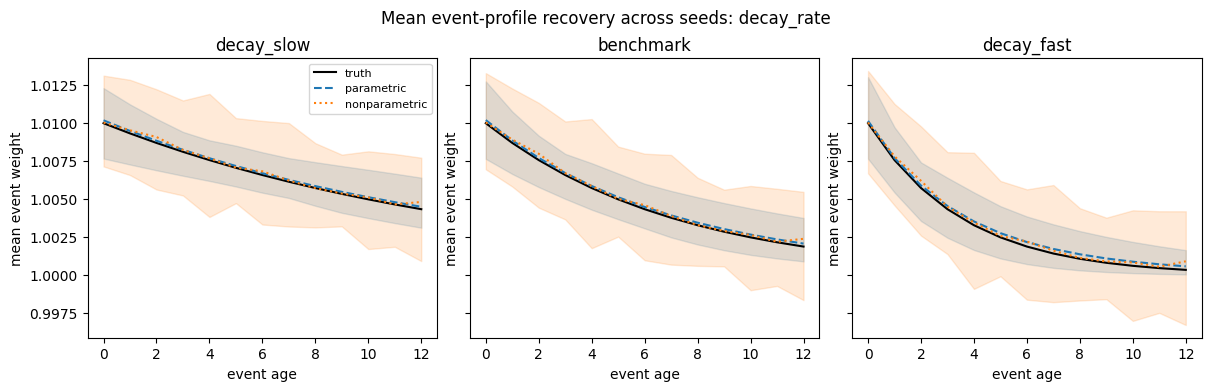

In [36]:
for family in family_order:
    family_cases = family_case_order[family]
    fig, axes = plt.subplots(1, len(family_cases), figsize=(4 * len(family_cases), 3.8), sharey=True, constrained_layout=True); axes = np.atleast_1d(axes)
    for axis, case_name in zip(axes, family_cases):
        data = profile_summary.loc[(profile_summary.case_name.eq(case_name)) & (profile_summary.profile_quantity.eq('event_weight'))]
        for method, style, color in [('truth', '-', 'black'), ('parametric', '--', 'tab:blue'), ('nonparametric', ':', 'tab:orange')]:
            subset = data.loc[data.profile_method.eq(method)].sort_values('event_age')
            axis.plot(subset.event_age, subset['mean'], linestyle=style, color=color, label=method)
            if method != 'truth': axis.fill_between(subset.event_age, subset.q05, subset.q95, color=color, alpha=.16)
        axis.set(title=case_name, xlabel='event age', ylabel='mean event weight')
    axes[0].legend(fontsize=8); fig.suptitle(f'Mean event-profile recovery across seeds: {family}')
    final_figures[f'profile_{family}.png'] = fig
    plt.show()

## Figure 6 — Known-DGP forecasting gap

The Known-DGP reference is a truth-based evaluation benchmark unavailable to fitted models. The fitted-to-Known-DGP RMSE gap shows residual forecast error from estimating the event response and other components; small negative values, if present, are retained.

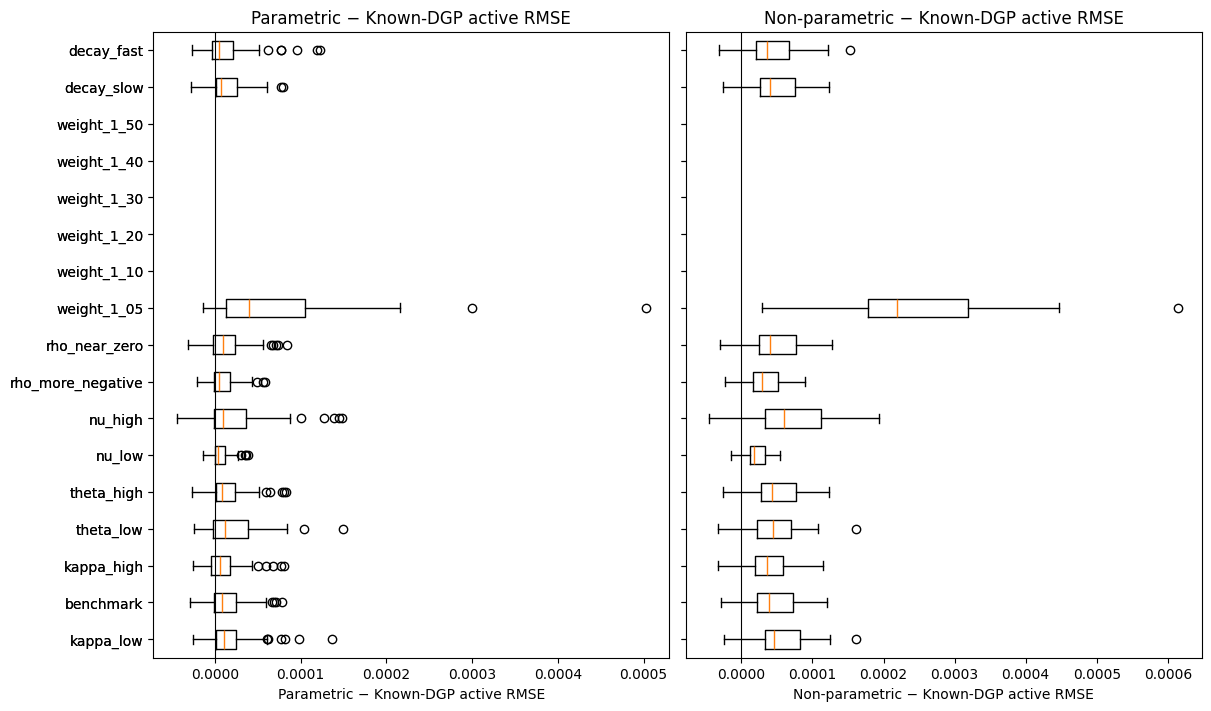

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True, constrained_layout=True)
for axis, metric, label in zip(axes, ['parametric_known_dgp_active_RMSE_gap', 'nonparametric_known_dgp_active_RMSE_gap'], ['Parametric − Known-DGP active RMSE', 'Non-parametric − Known-DGP active RMSE']):
    data = [plot_values(case, metric) for case in plot_case_order]
    axis.boxplot(data, vert=False, tick_labels=plot_case_order, showfliers=True); axis.axvline(0, color='black', linewidth=.8); axis.set(xlabel=label, title=label)
final_figures['known_dgp_rmse_gap.png'] = fig
plt.show()

## Save final robustness figures

The final repeated-seed figures are saved at reasonable resolution for use outside the notebook. Earlier one-seed prototype figures are not included in this final robustness export.

In [38]:
FIGURES_DIR = RESULTS_DIR / 'figures'; FIGURES_DIR.mkdir(exist_ok=True)
for filename, figure in final_figures.items(): figure.savefig(FIGURES_DIR / filename, dpi=180, bbox_inches='tight')
assert {'detection_robustness.png', 'profile_rmse.png', 'forecast_mae_gains.png', 'coverage_error.png', 'interval_scores.png', 'known_dgp_rmse_gap.png', 'profile_amplitude.png', 'profile_decay_rate.png'}.issubset(final_figures)

## Paired parameter-sensitivity evidence

Every alternative case is compared with its benchmark counterpart from the same seed:

$$D_{s,c}=M_{s,c}-M_{s,\mathrm{benchmark}}.$$

The 95% interval describes Monte Carlo uncertainty in the mean paired difference over 50 seeds. It is a compact supplement to the complete exported paired-contrast table.

In [39]:
paired_evidence_metrics = [
    'parametric_active_MAE_gain_pct', 'nonparametric_active_MAE_gain_pct',
    'parametric_profile_RMSE', 'nonparametric_profile_RMSE',
    'parametric_95_state_coverage_error', 'nonparametric_95_state_coverage_error',
    'parametric_known_dgp_active_RMSE_gap', 'nonparametric_known_dgp_active_RMSE_gap',
]
paired_evidence = paired_contrast_summary.loc[
    paired_contrast_summary['metric'].isin(paired_evidence_metrics),
    ['case_name', 'parameter', 'parameter_value', 'metric', 'mean_difference', 'ci_95_lower', 'ci_95_upper', 'median_difference'],
].sort_values(['parameter', 'parameter_value', 'metric'])
display(paired_evidence)

,case_name,parameter,parameter_value,metric,mean_difference,ci_95_lower,ci_95_upper,median_difference
131,weight_1_05,amplitude,0.05,nonparametric_95_state_coverage_error,0.056000,0.043233,0.068767,0.053846
133,weight_1_05,amplitude,0.05,nonparametric_active_MAE_gain_pct,72.696475,70.482651,74.910298,71.485758
135,weight_1_05,amplitude,0.05,nonparametric_known_dgp_active_RMSE_gap,0.000201,0.000175,0.000228,0.000184
136,weight_1_05,amplitude,0.05,nonparametric_profile_RMSE,-0.000418,-0.000450,-0.000387,-0.000420
137,weight_1_05,amplitude,0.05,parametric_95_state_coverage_error,0.011714,0.002724,0.020705,0.000000
...,...,...,...,...,...,...,...,...
110,theta_high,theta,0.25,nonparametric_profile_RMSE,-0.000121,-0.000130,-0.000113,-0.000121
111,theta_high,theta,0.25,parametric_95_state_coverage_error,0.000923,-0.000312,0.002158,0.000000
113,theta_high,theta,0.25,parametric_active_MAE_gain_pct,6.134432,5.828296,6.440568,6.044814
115,theta_high,theta,0.25,parametric_known_dgp_active_RMSE_gap,0.000001,-0.000001,0.000003,0.000001


## Heterogeneous High-Weight Viability and Conditional Recovery

This compact extension fixes the periodic calendar, shared decay, response horizon, and deterministic occurrence sequence $w_j\in\{1.10,1.25,1.50,1.75,2.00\}$, cycling over event occurrences. It is primarily a numerical-viability experiment. Only complete valid paths are eligible for retrospective pooled and event-specific recovery; no fitted event weight is used as an ex-ante forecast.


In [40]:
heterogeneous_weight_sequence = np.array([1.10,1.25,1.50,1.75,2.00], dtype=float)
heterogeneous_config = make_case_config(benchmark_case, label='heterogeneous_high_weight')

def heterogeneous_event_weight(t, event_times, params):
    elapsed = t - np.asarray(event_times, dtype=float)
    active = np.flatnonzero((elapsed >= -1e-12) & (elapsed <= params['response_horizon'] + 1e-12))
    if len(active) == 0: return 1.0
    event_id = int(active[0]); amplitude = heterogeneous_weight_sequence[event_id % len(heterogeneous_weight_sequence)] - 1.0
    return 1.0 + amplitude * np.exp(-params['decay_rate'] * elapsed[event_id])
heterogeneous_event_weight.__name__ = 'heterogeneous_event_weight'
heterogeneous_functions = {'event_weight_fn': heterogeneous_event_weight}
heterogeneous_failure_columns = ['experiment','configuration','seed','stage','exception_type','exception_message','simulation_valid','first_failed_transition','active_event_id','active_true_event_weight','event_age','maximum_volatility_before_failure','minimum_euler_price_update_factor','nonpositive_price_transition']
heterogeneous_rows, heterogeneous_failures = [], []
for seed in SEEDS:
    shock_bank = make_shock_bank(benchmark_case, seed=seed)
    try:
        simulation_pack = simulate_case(heterogeneous_config, shock_bank=shock_bank, functions=heterogeneous_functions)
        simulation = simulation_pack['simulation']; factors = 1 + simulation['states']['sigma'].iloc[:-1].to_numpy() * simulation['transitions']['epsilon'].to_numpy()
        heterogeneous_rows.append({'seed':seed,'simulation_valid':True,'first_failed_transition':np.nan,'active_event_id':np.nan,'active_true_event_weight':np.nan,'event_age':np.nan,'maximum_volatility_before_failure':simulation['states']['sigma'].max(),'minimum_euler_price_update_factor':factors.min(),'nonpositive_price_transition':False,'exception_type':None,'exception_message':None})
    except Exception as exc:
        d = diagnose_frozen_simulation(heterogeneous_config, shock_bank, functions=heterogeneous_functions); event_id = d['active_event_id_at_failure']
        true_weight = heterogeneous_weight_sequence[int(event_id) % len(heterogeneous_weight_sequence)] if pd.notna(event_id) else np.nan
        row = {'seed':seed,'simulation_valid':False,'first_failed_transition':d['first_failed_transition'],'active_event_id':event_id,'active_true_event_weight':true_weight,'event_age':d['active_event_age_at_failure'],'maximum_volatility_before_failure':d['maximum_volatility_before_failure'],'minimum_euler_price_update_factor':d['minimum_euler_price_update_factor'],'nonpositive_price_transition':d['nonpositive_price_transition'],'exception_type':type(exc).__name__,'exception_message':str(exc)}
        heterogeneous_rows.append(row); heterogeneous_failures.append({'experiment':'heterogeneous_high_weight','configuration':'heterogeneous_high_weight','seed':seed,'stage':'simulation','exception_type':row['exception_type'],'exception_message':row['exception_message'],'simulation_valid':False,'first_failed_transition':row['first_failed_transition'],'active_event_id':row['active_event_id'],'active_true_event_weight':row['active_true_event_weight'],'event_age':row['event_age'],'maximum_volatility_before_failure':row['maximum_volatility_before_failure'],'minimum_euler_price_update_factor':row['minimum_euler_price_update_factor'],'nonpositive_price_transition':row['nonpositive_price_transition']})
heterogeneous_results = pd.DataFrame(heterogeneous_rows); heterogeneous_failure_log = pd.DataFrame(heterogeneous_failures, columns=heterogeneous_failure_columns)
heterogeneous_prototype = heterogeneous_results.loc[heterogeneous_results.seed.eq(prototype_seed)].copy()
heterogeneous_viability_summary = pd.DataFrame([{'configuration':'heterogeneous_high_weight','sequence':'1.10, 1.25, 1.50, 1.75, 2.00','attempted_seeds':len(SEEDS),'valid_path_count':int(heterogeneous_results.simulation_valid.sum()),'invalid_path_count':int((~heterogeneous_results.simulation_valid).sum()),'survival_proportion':heterogeneous_results.simulation_valid.mean(),'median_first_failure_transition':heterogeneous_results.loc[~heterogeneous_results.simulation_valid,'first_failed_transition'].median(),'mean_maximum_volatility_before_failure':heterogeneous_results.maximum_volatility_before_failure.mean(),'minimum_euler_price_update_factor':heterogeneous_results.minimum_euler_price_update_factor.min()}])
heterogeneous_viability_summary.to_csv(RESULTS_DIR/'notebook08_heterogeneous_viability_summary.csv',index=False)
heterogeneous_failure_log.to_csv(RESULTS_DIR/'notebook08_heterogeneous_failure_log.csv',index=False)
display(heterogeneous_prototype)
display(heterogeneous_viability_summary)
display(heterogeneous_failure_log.groupby(['active_true_event_weight','event_age'],dropna=False).size().rename('failure_count').reset_index())


,seed,simulation_valid,first_failed_transition,active_event_id,active_true_event_weight,event_age,maximum_volatility_before_failure,minimum_euler_price_update_factor,nonpositive_price_transition,exception_type,exception_message
0,20260721,False,95,3.0,1.75,11.0,11.486125,-0.016191,True,ValueError,S_next is non-positive at transition 95.


,configuration,sequence,attempted_seeds,valid_path_count,invalid_path_count,survival_proportion,median_first_failure_transition,mean_maximum_volatility_before_failure,minimum_euler_price_update_factor
0,heterogeneous_high_weight,"1.10, 1.25, 1.50, 1.75, 2.00",50,0,50,0.0,98.5,17.691749,-5.470791


,active_true_event_weight,event_age,failure_count
0,1.75,6.0,1
1,1.75,7.0,2
2,1.75,8.0,2
3,1.75,9.0,3
4,1.75,10.0,3
5,1.75,11.0,3
6,1.75,12.0,5
7,2.00,0.0,1
8,2.00,1.0,2
9,2.00,2.0,4


### Conditional retrospective recovery

If at least one complete path survives, the pooled estimator retains one common amplitude and shared decay. The event-specific estimator fits one amplitude per observed event occurrence and one shared decay parameter from active training observations only. True sequence values are attached only after fitting for evaluation; pair-order scores exclude true-weight ties.


In [41]:
def fit_event_specific_shared_decay(result):
    train, baseline, timing = result['split']['train'], result['baseline'], result['timing']
    features = build_baseline_features(train, result['config']); baseline_prediction = np.asarray(baseline['model'].predict(sm.add_constant(features,has_constant='add')))
    active = train.event_active_i.eq(1); raw = train.loc[active,'state_next'].to_numpy()/baseline_prediction[active.to_numpy()]
    anchors = train.loc[active,'i'].to_numpy()-train.loc[active,'event_age_i'].to_numpy(); event_transitions = result['simulation']['transitions'].loc[result['simulation']['transitions'].event.eq(1),'i'].to_numpy()
    event_ids = np.searchsorted(event_transitions, anchors); ages = train.loc[active,'event_age_years_i'].to_numpy(); unique_ids, inverse = np.unique(event_ids,return_inverse=True)
    fit = least_squares(lambda p:(1+p[:-1][inverse]*np.exp(-p[-1]*ages))**0.5-raw, x0=np.r_[np.full(len(unique_ids),max(result['profiles']['A_hat'],1e-8)),max(result['profiles']['lambda_hat'],1e-8)], bounds=(np.zeros(len(unique_ids)+1),np.full(len(unique_ids)+1,np.inf)))
    fitted_weights = 1+fit.x[:-1]; return pd.DataFrame({'event_id':unique_ids,'weight_hat_event_specific':fitted_weights,'weight_hat_pooled':1+result['profiles']['A_hat']}), float(fit.x[-1]), bool(fit.success), str(fit.message)

heterogeneous_recovery_rows = []
for seed in heterogeneous_results.loc[heterogeneous_results.simulation_valid,'seed']:
    shock_bank = make_shock_bank(benchmark_case,seed=int(seed))
    try:
        result = run_full_pipeline(heterogeneous_config,shock_bank=shock_bank,functions=heterogeneous_functions,include_causality=False,include_intervals=False,include_truth=False)
        estimates, shared_lambda_hat, converged, message = fit_event_specific_shared_decay(result)
        estimates['weight_true'] = heterogeneous_weight_sequence[estimates.event_id.to_numpy()%len(heterogeneous_weight_sequence)]
        estimates['seed']=seed; estimates['shared_lambda_hat']=shared_lambda_hat; estimates['converged']=converged; estimates['optimisation_message']=message
        heterogeneous_recovery_rows.extend(estimates.to_dict('records'))
    except Exception as exc:
        heterogeneous_failures.append({'experiment':'heterogeneous_high_weight','configuration':'heterogeneous_high_weight','seed':seed,'stage':'event_specific_fit','exception_type':type(exc).__name__,'exception_message':str(exc),'simulation_valid':True,'first_failed_transition':np.nan,'active_event_id':np.nan,'active_true_event_weight':np.nan,'event_age':np.nan,'maximum_volatility_before_failure':np.nan,'minimum_euler_price_update_factor':np.nan,'nonpositive_price_transition':np.nan})
heterogeneous_recovery = pd.DataFrame(heterogeneous_recovery_rows)
heterogeneous_failure_log = pd.DataFrame(heterogeneous_failures,columns=heterogeneous_failure_columns)
if heterogeneous_recovery.empty:
    heterogeneous_recovery_summary = pd.DataFrame([{'recovery_defined':False,'reason':'No complete valid path was available for retrospective recovery.'}])
else:
    e = heterogeneous_recovery.copy(); e['event_specific_error']=e.weight_hat_event_specific-e.weight_true; e['pooled_error']=e.weight_hat_pooled-e.weight_true
    pairs=[]
    for _,g in e.groupby('seed'):
        for i in range(len(g)):
            for j in range(i+1,len(g)):
                true_diff=g.iloc[i].weight_true-g.iloc[j].weight_true
                if true_diff!=0: pairs.append(np.sign(true_diff)==np.sign(g.iloc[i].weight_hat_event_specific-g.iloc[j].weight_hat_event_specific))
    heterogeneous_recovery_summary=pd.DataFrame([{'recovery_defined':True,'event_specific_bias':e.event_specific_error.mean(),'event_specific_MAE':np.abs(e.event_specific_error).mean(),'event_specific_RMSE':np.sqrt(np.mean(e.event_specific_error**2)),'event_specific_median_absolute_error':np.median(np.abs(e.event_specific_error)),'event_specific_pearson':e.weight_true.corr(e.weight_hat_event_specific),'event_specific_spearman':e.weight_true.corr(e.weight_hat_event_specific,method='spearman'),'shared_decay_bias':e.shared_lambda_hat.mean()-heterogeneous_config['events']['decay_rate'],'shared_decay_MAE':np.abs(e.shared_lambda_hat-heterogeneous_config['events']['decay_rate']).mean(),'shared_decay_RMSE':np.sqrt(np.mean((e.shared_lambda_hat-heterogeneous_config['events']['decay_rate'])**2)),'pooled_event_level_MAE':np.abs(e.pooled_error).mean(),'pooled_event_level_RMSE':np.sqrt(np.mean(e.pooled_error**2)),'event_specific_improvement_over_pooled_MAE':np.abs(e.pooled_error).mean()-np.abs(e.event_specific_error).mean(),'event_specific_improvement_over_pooled_RMSE':np.sqrt(np.mean(e.pooled_error**2))-np.sqrt(np.mean(e.event_specific_error**2)),'total_event_pairs':len(e)*(len(e)-1)//2,'tied_pairs_excluded':len(e)*(len(e)-1)//2-len(pairs),'non_tied_pairs_evaluated':len(pairs),'correctly_ordered_non_tied_pairs':sum(pairs),'corrected_ordering_proportion':np.mean(pairs) if pairs else np.nan,'convergence_failures':int((~e.converged).sum()),'optimisation_warnings':int((~e.converged).sum())}])
    heterogeneous_recovery.to_csv(RESULTS_DIR/'notebook08_heterogeneous_recovery.csv',index=False)
heterogeneous_failure_log.to_csv(RESULTS_DIR/'notebook08_heterogeneous_failure_log.csv',index=False)
display(heterogeneous_recovery_summary)
if not heterogeneous_recovery.empty:
    fig,axis=plt.subplots(figsize=(5,4),constrained_layout=True); axis.scatter(heterogeneous_recovery.weight_true,heterogeneous_recovery.weight_hat_event_specific); axis.plot([1.1,2.0],[1.1,2.0],color='black'); axis.set(xlabel='true initial event weight',ylabel='retrospective event-specific estimate',title='Heterogeneous valid-path recovery'); plt.show()


,recovery_defined,reason
0,False,No complete valid path was available for retro...


## Repeated-seed findings

The non-amplitude $\kappa$, $\theta$, $\nu$, $\rho$, and $\lambda$ sensitivity analyses, causal diagnostics, event-profile recovery, forecasting, calibration, Known-DGP reference gap, paired contrasts, and their existing figures are retained unchanged. Their numerical summaries remain the appropriate evidence for those parameter families.

### Revised common-weight family

The new common initial-weight grid is $w\in\{1.05,1.10,1.20,1.30,1.40,1.50\}$, corresponding to $A=w-1\in\{0.05,0.10,0.20,0.30,0.40,0.50\}$. The former $w=1.05$ maximum is now the first high-signal case, not a weak-signal ceiling. The survival table distinguishes invalid simulator paths from fitting failures after valid simulation. Recovery, GC, TDMI, forecasting, and calibration quantities in the common-weight recovery table are conditional on complete valid paths; unavailable quantities remain missing rather than zero.

A path that becomes invalid does so before estimation, so it cannot be interpreted as weak causal performance or weak parameter identification. It instead indicates incompatibility of the tested repeated multiplier with the current Euler price process under that shock realisation. GC, TDMI, and transfer-entropy diagnostics remain predictive or statistical diagnostics rather than proof of interventionist causality.

### Heterogeneous extension

The fixed occurrence sequence $w_j\in\{1.10,1.25,1.50,1.75,2.00\}$ is assessed first for viability over 50 paired shock seeds. If no complete valid path exists, retrospective event-specific recovery is undefined rather than replaced with a lower-weight fallback. If valid paths exist, pooled and event-specific estimates are recovery estimates using post-event observations, not ex-ante forecasts for the same event.


In [42]:
common_complete = common_weight_survival.loc[common_weight_survival.valid_path_count.gt(0),'initial_event_weight'].tolist()
common_invalid = common_weight_survival.loc[common_weight_survival.invalid_path_count.gt(0),'initial_event_weight'].tolist()
valid_weight_recovery = common_weight_recovery.loc[common_weight_recovery.valid_complete_paths.notna()]
hetero_valid = int(heterogeneous_viability_summary.valid_path_count.iloc[0])
weight_105 = valid_weight_recovery.loc[valid_weight_recovery.initial_event_weight.eq(1.05)].iloc[0] if not valid_weight_recovery.empty and valid_weight_recovery.initial_event_weight.eq(1.05).any() else None
print('Updated amplitude conclusions')
print('Common weights 1.05, 1.10, 1.20, 1.30, 1.40 and 1.50 correspond to amplitudes 0.05, 0.10, 0.20, 0.30, 0.40 and 0.50.')
print(f'Complete valid paths occurred at {common_complete}; simulations failed before estimation at {common_invalid}.')
if weight_105 is not None:
    print(f"For w=1.05, conditional recovery over {int(weight_105.valid_complete_paths)} complete paths: weight MAE={weight_105.weight_MAE:.6f}, weight RMSE={weight_105.weight_RMSE:.6f}, decay MAE={weight_105.decay_MAE:.3f}, active MAE={weight_105.active_period_forecast_MAE:.6f}, mean MAE gain={weight_105.forecast_improvement_over_no_event_pct:.2f}%.")
print(f'Heterogeneous weights 1.10 to 2.00 produced {hetero_valid} complete valid paths across 50 paired seeds; event-specific recovery is therefore undefined and would be retrospective, not ex-ante, if it were estimable.')


Updated amplitude conclusions
Common weights 1.05, 1.10, 1.20, 1.30, 1.40 and 1.50 correspond to amplitudes 0.05, 0.10, 0.20, 0.30, 0.40 and 0.50.
Complete valid paths occurred at [1.05]; simulations failed before estimation at [1.1, 1.2, 1.3, 1.4, 1.5].
For w=1.05, conditional recovery over 50 complete paths: weight MAE=0.000836, weight RMSE=0.001037, decay MAE=0.886, active MAE=0.000780, mean MAE gain=94.08%.
Heterogeneous weights 1.10 to 2.00 produced 0 complete valid paths across 50 paired seeds; event-specific recovery is therefore undefined and would be retrospective, not ex-ante, if it were estimable.


## Limitations

Only 50 shock realisations are used; scalar parameters vary one at a time; the event calendar is dense and deterministic; and results are synthetic rather than evidence of empirical market causality. Absolute RMSE and interval scores remain scale-dependent, while paired contrasts and relative gains help comparison.

High-weight collapse is a numerical property of the unchanged repeated-multiplier Euler price process at the tested calibration. It does not by itself establish that the weights are economically unrealistic. No log-price reformulation, positivity-preserving scheme, clipping, rescaled shocks, alternative horizon, or event removal is introduced here. The heterogeneous extension is primarily a viability and retrospective recovery assessment, not an ex-ante event-weight forecasting exercise.


## Final Notebook 08 checkpoint

Notebook 08 retains the frozen full scalar-robustness workflow and replaces only its amplitude family with the common high-weight grid. It additionally exports concise common-weight survival, conditional recovery, and failure tables plus a heterogeneous high-weight viability extension. All non-amplitude checkpoint outputs and analyses remain in place.

Freeze Notebook 08
        ->
Update Notebook 13 once
        ->
Freeze Notebook 13
        ->
Begin Notebook 14


In [43]:
import nbformat
required_checkpoint_files = [
    RESULTS_DIR/'notebook08_run_level_results.csv', RESULTS_DIR/'notebook08_event_age_profiles.csv', RESULTS_DIR/'notebook08_failures.csv',
    RESULTS_DIR/'notebook08_common_weight_survival.csv', RESULTS_DIR/'notebook08_common_weight_valid_path_recovery.csv', RESULTS_DIR/'notebook08_common_weight_failure_log.csv',
    RESULTS_DIR/'notebook08_heterogeneous_viability_summary.csv', RESULTS_DIR/'notebook08_heterogeneous_failure_log.csv',
]
assert all(path.exists() for path in required_checkpoint_files)
notebook_check = nbformat.read('08_n1_scalar_parameter_and_replication_robustness.ipynb',as_version=4)
headings = [cell.source.splitlines()[0] for cell in notebook_check.cells if cell.cell_type=='markdown' and cell.source.startswith('#')]
for heading in ['## 2. Load the frozen workflow',r'## 4. Mean-reversion speed ($\kappa$)',r'## 5. Long-run volatility level ($\theta$)',r'## 6. Volatility innovation scale ($\nu$)',r'## 7. Return-volatility correlation ($\rho$)',r'## 9. Event-decay rate ($\lambda$)']:
    assert heading in headings
assert any('Forecast gains' in heading for heading in headings)
assert any('Calibration' in heading for heading in headings)
assert any('Known-DGP forecasting gap' in heading for heading in headings)
assert len(notebook_check.cells) >= 85 and len(notebook_check.cells) <= 104 and len(notebook_check.cells)-94 <= 10
assert not set(['amplitude_moderate','amplitude_strong','amplitude_extreme']).intersection(case_registry.case_name)
assert np.allclose(heterogeneous_weight_sequence,[1.10,1.25,1.50,1.75,2.00])
assert set(common_weight_case_names) == set(case_registry.loc[case_registry.parameter.eq('amplitude'),'case_name'])
print(f'Notebook 08 completion status: {successful_run_count}/{planned_runs} successful full pipelines; figures saved: {len(final_figures)}; common-weight and heterogeneous checkpoints exported to {RESULTS_DIR}.')


Notebook 08 completion status: 600/850 successful full pipelines; figures saved: 12; common-weight and heterogeneous checkpoints exported to notebook08_results.
